In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [2]:
app = pd.read_csv('/content/application_data.txt')
papp = pd.read_csv('/content/previous_application.txt')

In [3]:
app.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
app.shape

(307511, 122)

In [5]:
papp.shape

(1670214, 37)

In [6]:
app.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 122 columns):
 #    Column                        Non-Null Count   Dtype  
---   ------                        --------------   -----  
 0    SK_ID_CURR                    307511 non-null  int64  
 1    TARGET                        307511 non-null  int64  
 2    NAME_CONTRACT_TYPE            307511 non-null  object 
 3    CODE_GENDER                   307511 non-null  object 
 4    FLAG_OWN_CAR                  307511 non-null  object 
 5    FLAG_OWN_REALTY               307511 non-null  object 
 6    CNT_CHILDREN                  307511 non-null  int64  
 7    AMT_INCOME_TOTAL              307511 non-null  float64
 8    AMT_CREDIT                    307511 non-null  float64
 9    AMT_ANNUITY                   307499 non-null  float64
 10   AMT_GOODS_PRICE               307233 non-null  float64
 11   NAME_TYPE_SUITE               306219 non-null  object 
 12   NAME_INCOME_TYPE            

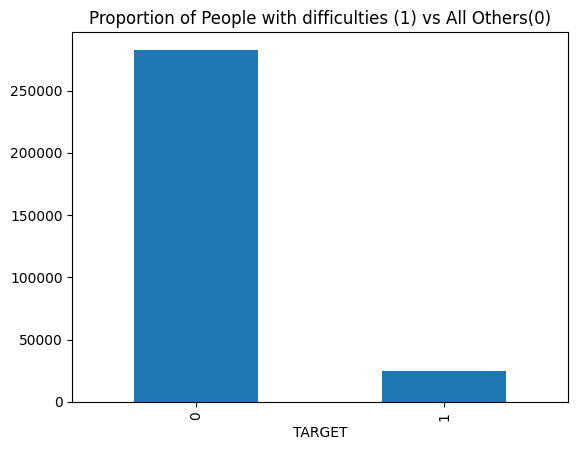

In [7]:
app.TARGET.value_counts().plot(kind='bar', title='Proportion of People with difficulties (1) vs All Others(0)')
plt.show()

#Our Data is imbalanced since only 8% of applicants have difficulties in paying their loans

## Analyzing basic demographic data w.r.to difficulties

In [8]:
app.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


### Data Wrangling

In [9]:
#Obtaining columns with more than 40% missing values
null_columns = app.columns[app.isnull().sum() / len(app) * 100 > 40.0]

In [10]:
null_columns

Index(['OWN_CAR_AGE', 'EXT_SOURCE_1', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG',
       'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG',
       'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMAX_AVG', 'FLOORSMIN_AVG',
       'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG',
       'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG', 'APARTMENTS_MODE',
       'BASEMENTAREA_MODE', 'YEARS_BEGINEXPLUATATION_MODE', 'YEARS_BUILD_MODE',
       'COMMONAREA_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMAX_MODE',
       'FLOORSMIN_MODE', 'LANDAREA_MODE', 'LIVINGAPARTMENTS_MODE',
       'LIVINGAREA_MODE', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAREA_MODE',
       'APARTMENTS_MEDI', 'BASEMENTAREA_MEDI', 'YEARS_BEGINEXPLUATATION_MEDI',
       'YEARS_BUILD_MEDI', 'COMMONAREA_MEDI', 'ELEVATORS_MEDI',
       'ENTRANCES_MEDI', 'FLOORSMAX_MEDI', 'FLOORSMIN_MEDI', 'LANDAREA_MEDI',
       'LIVINGAPARTMENTS_MEDI', 'LIVINGAREA_MEDI', 'NONLIVINGAPARTMENTS_MEDI',
       'NONLIVINGAREA_MEDI', 'FO

In [11]:
len(null_columns)

49

In [12]:
##Removing Columns which have more than 40% null values
app.drop(null_columns, axis=1, inplace=True)

In [13]:
app.shape

(307511, 73)

In [14]:
null_columns2 = app.columns[app.isnull().sum() > 0]

In [15]:
null_columns2

Index(['AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE', 'OCCUPATION_TYPE',
       'CNT_FAM_MEMBERS', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
       'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE',
       'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE',
       'DAYS_LAST_PHONE_CHANGE', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='object')

In [16]:
len(null_columns2)

18

In [17]:
##Further removal of columns which are densely centered around 0 i.e. having no variation
app.drop(['DEF_60_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE', 'OBS_30_CNT_SOCIAL_CIRCLE',
 'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY','AMT_REQ_CREDIT_BUREAU_WEEK','AMT_REQ_CREDIT_BUREAU_MON',
 'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR'], axis=1, inplace= True)

In [18]:
app.shape

(307511, 63)

In [19]:
app.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 63 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   SK_ID_CURR                   307511 non-null  int64  
 1   TARGET                       307511 non-null  int64  
 2   NAME_CONTRACT_TYPE           307511 non-null  object 
 3   CODE_GENDER                  307511 non-null  object 
 4   FLAG_OWN_CAR                 307511 non-null  object 
 5   FLAG_OWN_REALTY              307511 non-null  object 
 6   CNT_CHILDREN                 307511 non-null  int64  
 7   AMT_INCOME_TOTAL             307511 non-null  float64
 8   AMT_CREDIT                   307511 non-null  float64
 9   AMT_ANNUITY                  307499 non-null  float64
 10  AMT_GOODS_PRICE              307233 non-null  float64
 11  NAME_TYPE_SUITE              306219 non-null  object 
 12  NAME_INCOME_TYPE             307511 non-null  object 
 13 

In [20]:
dem_attr = ['CODE_GENDER', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE'] ##personal attributes
emp_attr = ['NAME_INCOME_TYPE' ,'ORGANIZATION_TYPE', 'OCCUPATION_TYPE'] #Employment attributes
loan_attr = ['NAME_CONTRACT_TYPE', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE'] #loan attributes
cont_attr = ['FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL'] #contact attributes
document_attr = ['FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_5', 'FLAG_DOCUMENT_6',
                 'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_8', 'FLAG_DOCUMENT_9', 'FLAG_DOCUMENT_10', 'FLAG_DOCUMENT_11',
                 'FLAG_DOCUMENT_12', 'FLAG_DOCUMENT_13', 'FLAG_DOCUMENT_14', 'FLAG_DOCUMENT_15', 'FLAG_DOCUMENT_16',
                 'FLAG_DOCUMENT_17', 'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_21'] #document attributes

### Some of the categorical variables contain null values and I am just imputing them as 'UNK' class. The custom function below handles this preprocessing and plots categorical variables passed via list

In [21]:
def plot_category_group(dataframe, col_list, target, group_name, n_cols =2):
    """ Fills missing values with 'UNK', checks category counts, and plots a list of
        columns in a clean grid layout"""

    print(f"\n" + "=" * 40)
    print(f" VISUALIZING: {group_name.upper()}")
    print("=" * 40)

    #handle missing values for specific group
    df_temp = dataframe.copy()
    df_temp[col_list] = df_temp[col_list].fillna("UNK")

    #calculate the grid structure
    n_rows = math.ceil(len(col_list)/n_cols)

    #creating the grid
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 4.5))

    #handling edge cases where there is only one plot in the list
    if len(col_list) == 1:
      axes = [axes]
    else:
      axes = axes.flatten()

    #loop and plot
    for i,col in enumerate(col_list):
      num_categories = df_temp[col].nunique()

      if num_categories > 2:
        sns.countplot(data =df_temp, y=col, hue=target, ax =axes[i])
        axes[i].set_ylabel(col)
        axes[i].set_xlabel("count")

      else:
        sns.countplot(data=df_temp, x=col, hue=target, ax=axes[i])
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("count")

      axes[i].set_title(f"{col} ({num_categories}) Categories")

    #Removin blank plots
    for j in range(i+1, len(axes)):
      fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()




 VISUALIZING: PERSONAL ATTRIBUTES


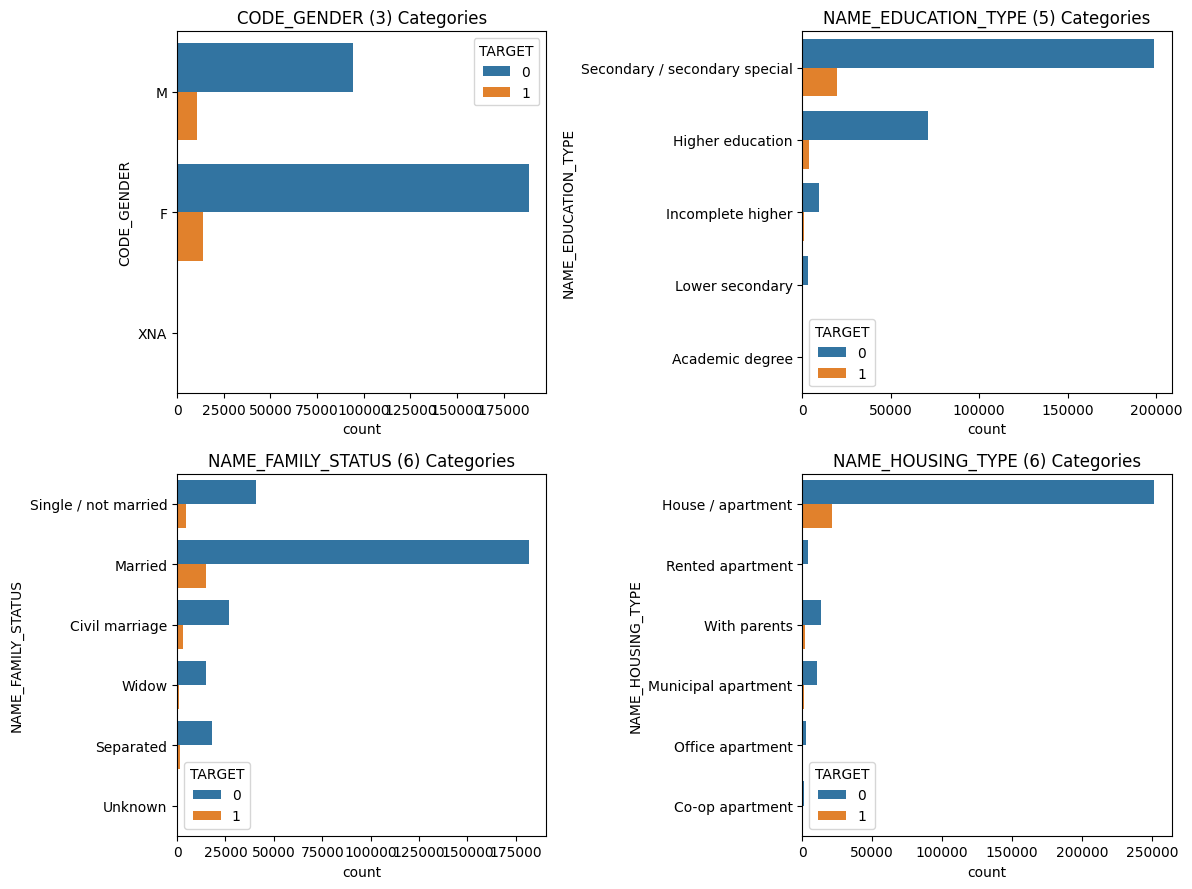

In [ ]:
plot_category_group(app, dem_attr, target="TARGET", group_name="Personal Attributes")


 VISUALIZING: EMPLOYMENT ATTRIBUTES


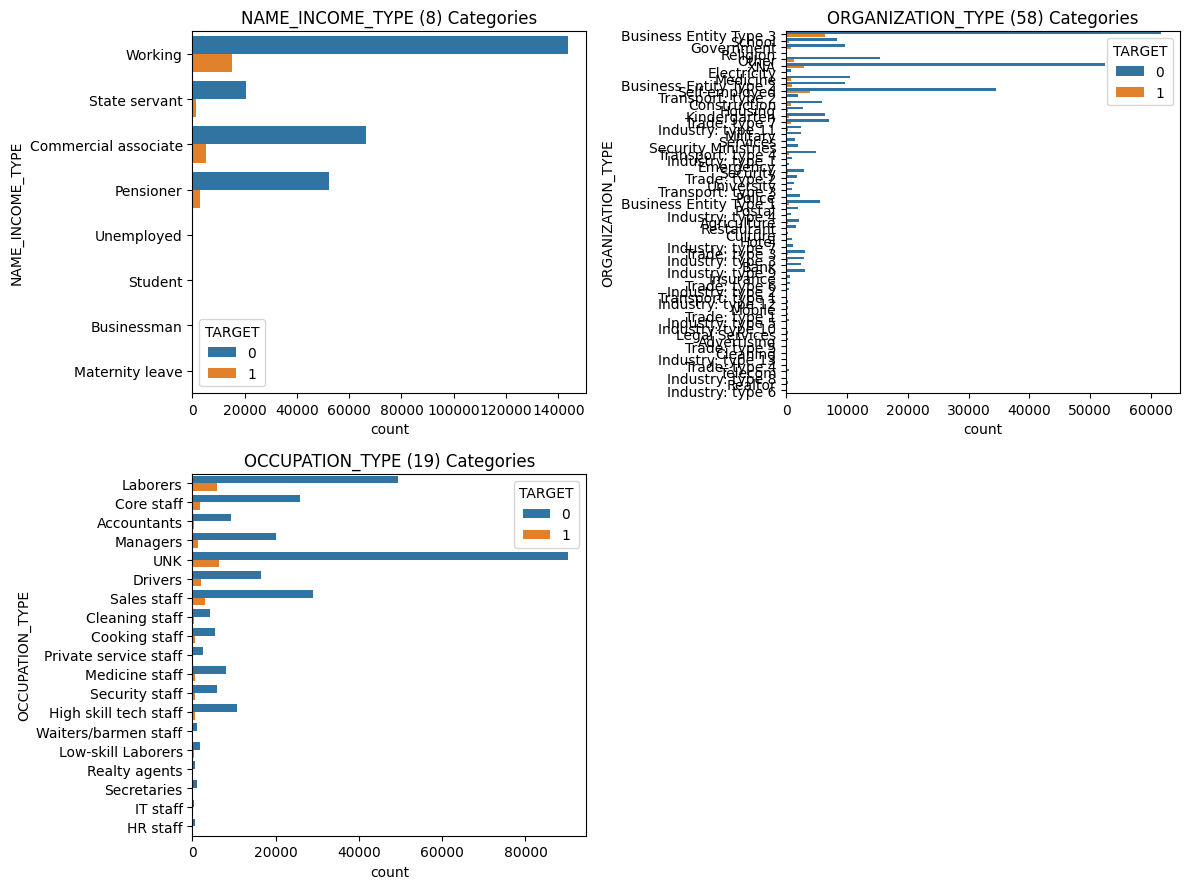

In [ ]:
plot_category_group(app, emp_attr, target="TARGET", group_name="Employment Attributes")

###Further inspecting Organization Type

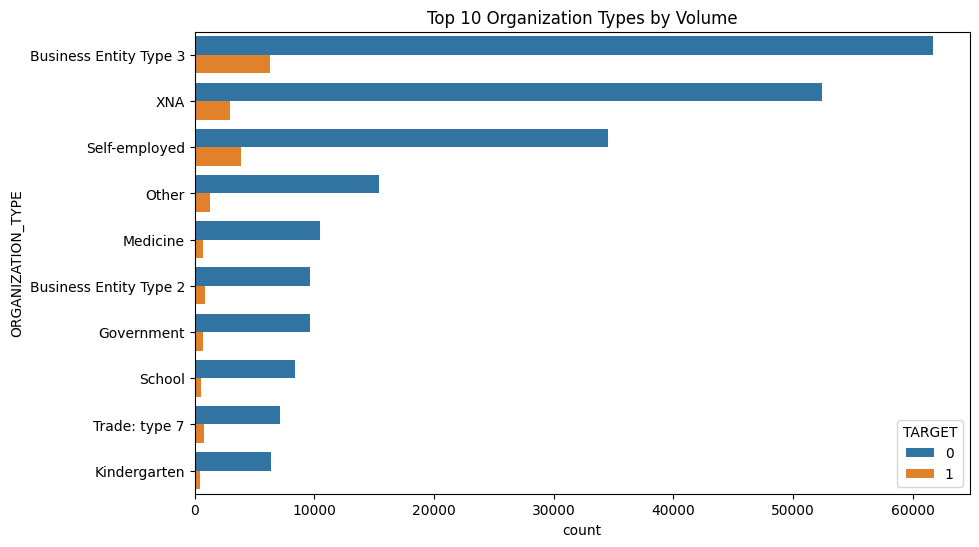

In [ ]:
#inspecting organization type
# 1. Get the list of top 10 category names by raw volume
top_10_orgs = app['ORGANIZATION_TYPE'].value_counts().head(10).index

# 2. Filter the original dataframe and plot using seaborn
plt.figure(figsize=(10, 6))
sns.countplot(
    data=app[app['ORGANIZATION_TYPE'].isin(top_10_orgs)],
    y='ORGANIZATION_TYPE',
    hue='TARGET',
    order=top_10_orgs  # Keeps them sorted beautifully from highest to lowest count
)
plt.title('Top 10 Organization Types by Volume')
plt.show()


 VISUALIZING: LOAN ATTRIBUTES


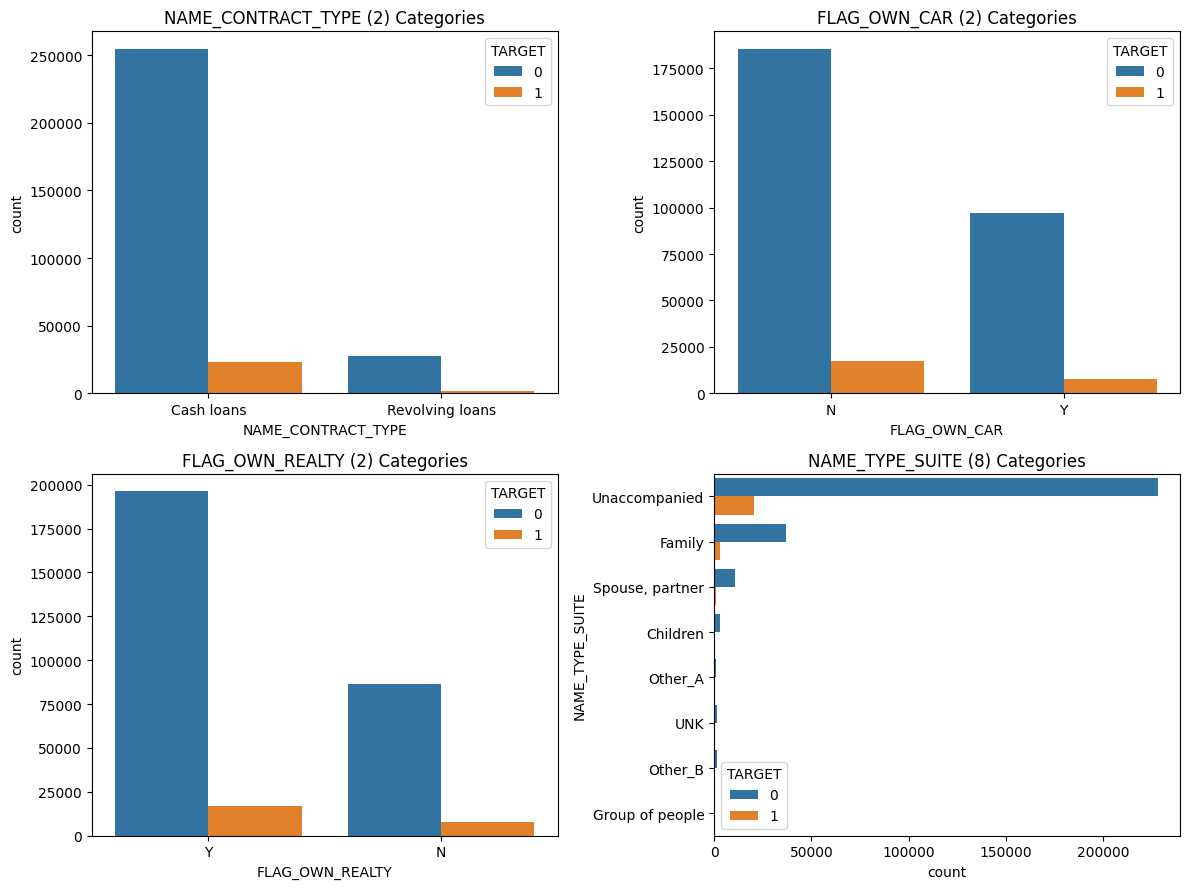

In [ ]:
plot_category_group(app, loan_attr, target="TARGET", group_name="Loan Attributes")


 VISUALIZING: CONTACT ATTRIBUTES


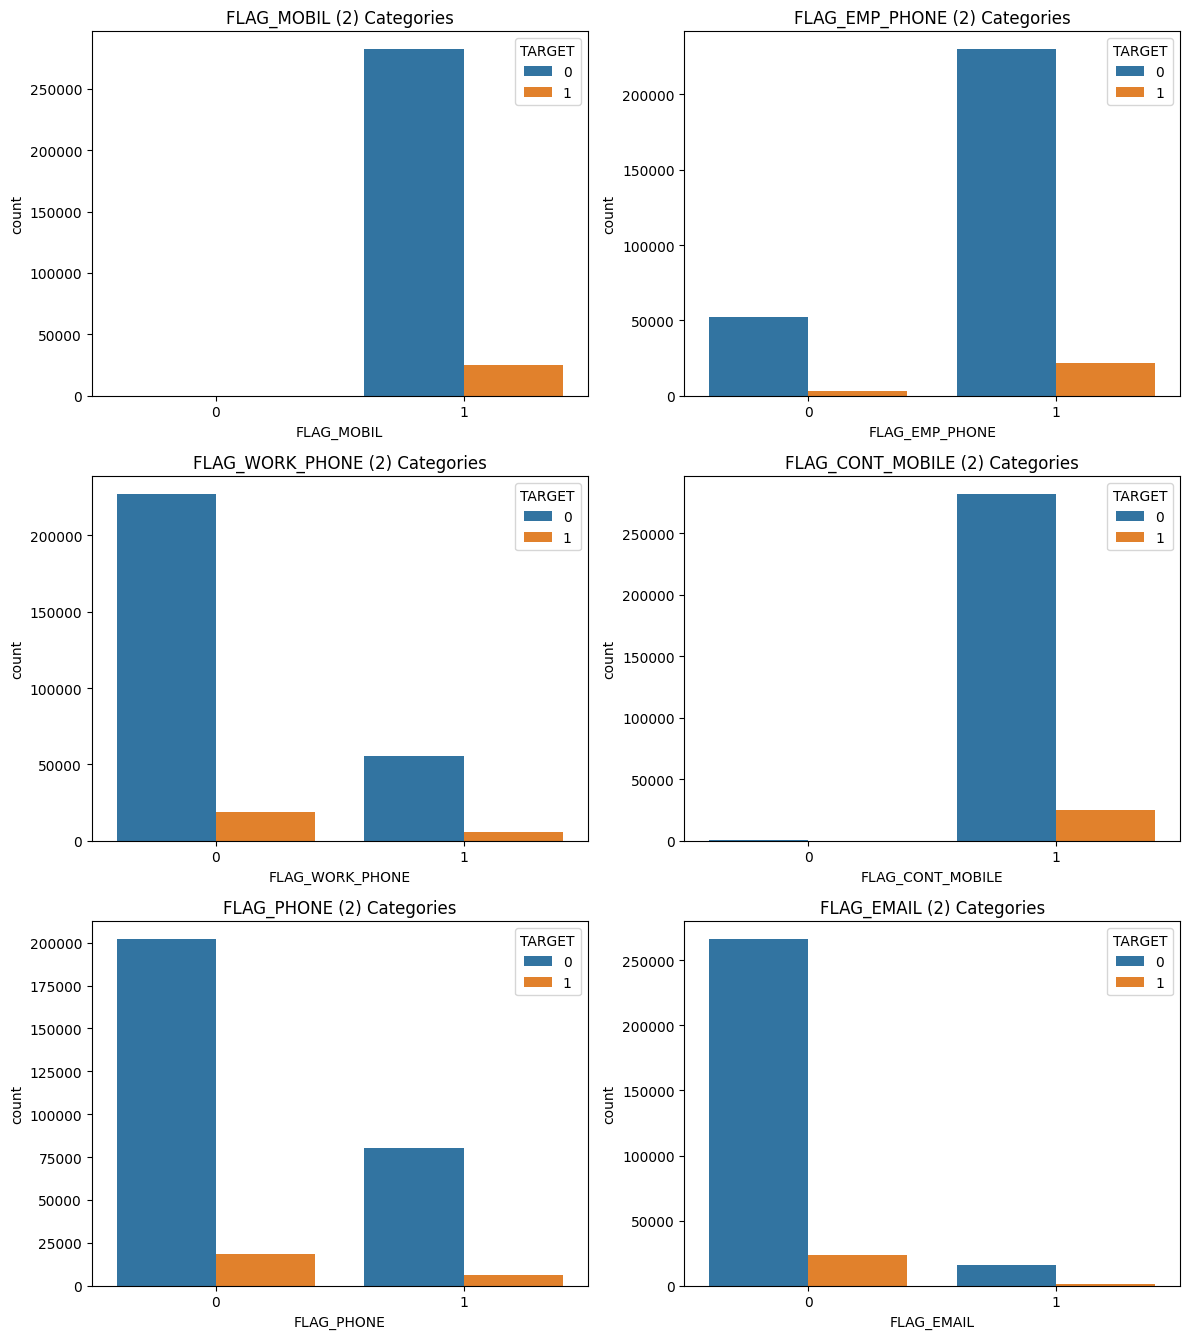

In [ ]:
plot_category_group(app, cont_attr, target="TARGET", group_name="Contact Attributes")


 VISUALIZING: DOCUMENT ATTRIBUTES


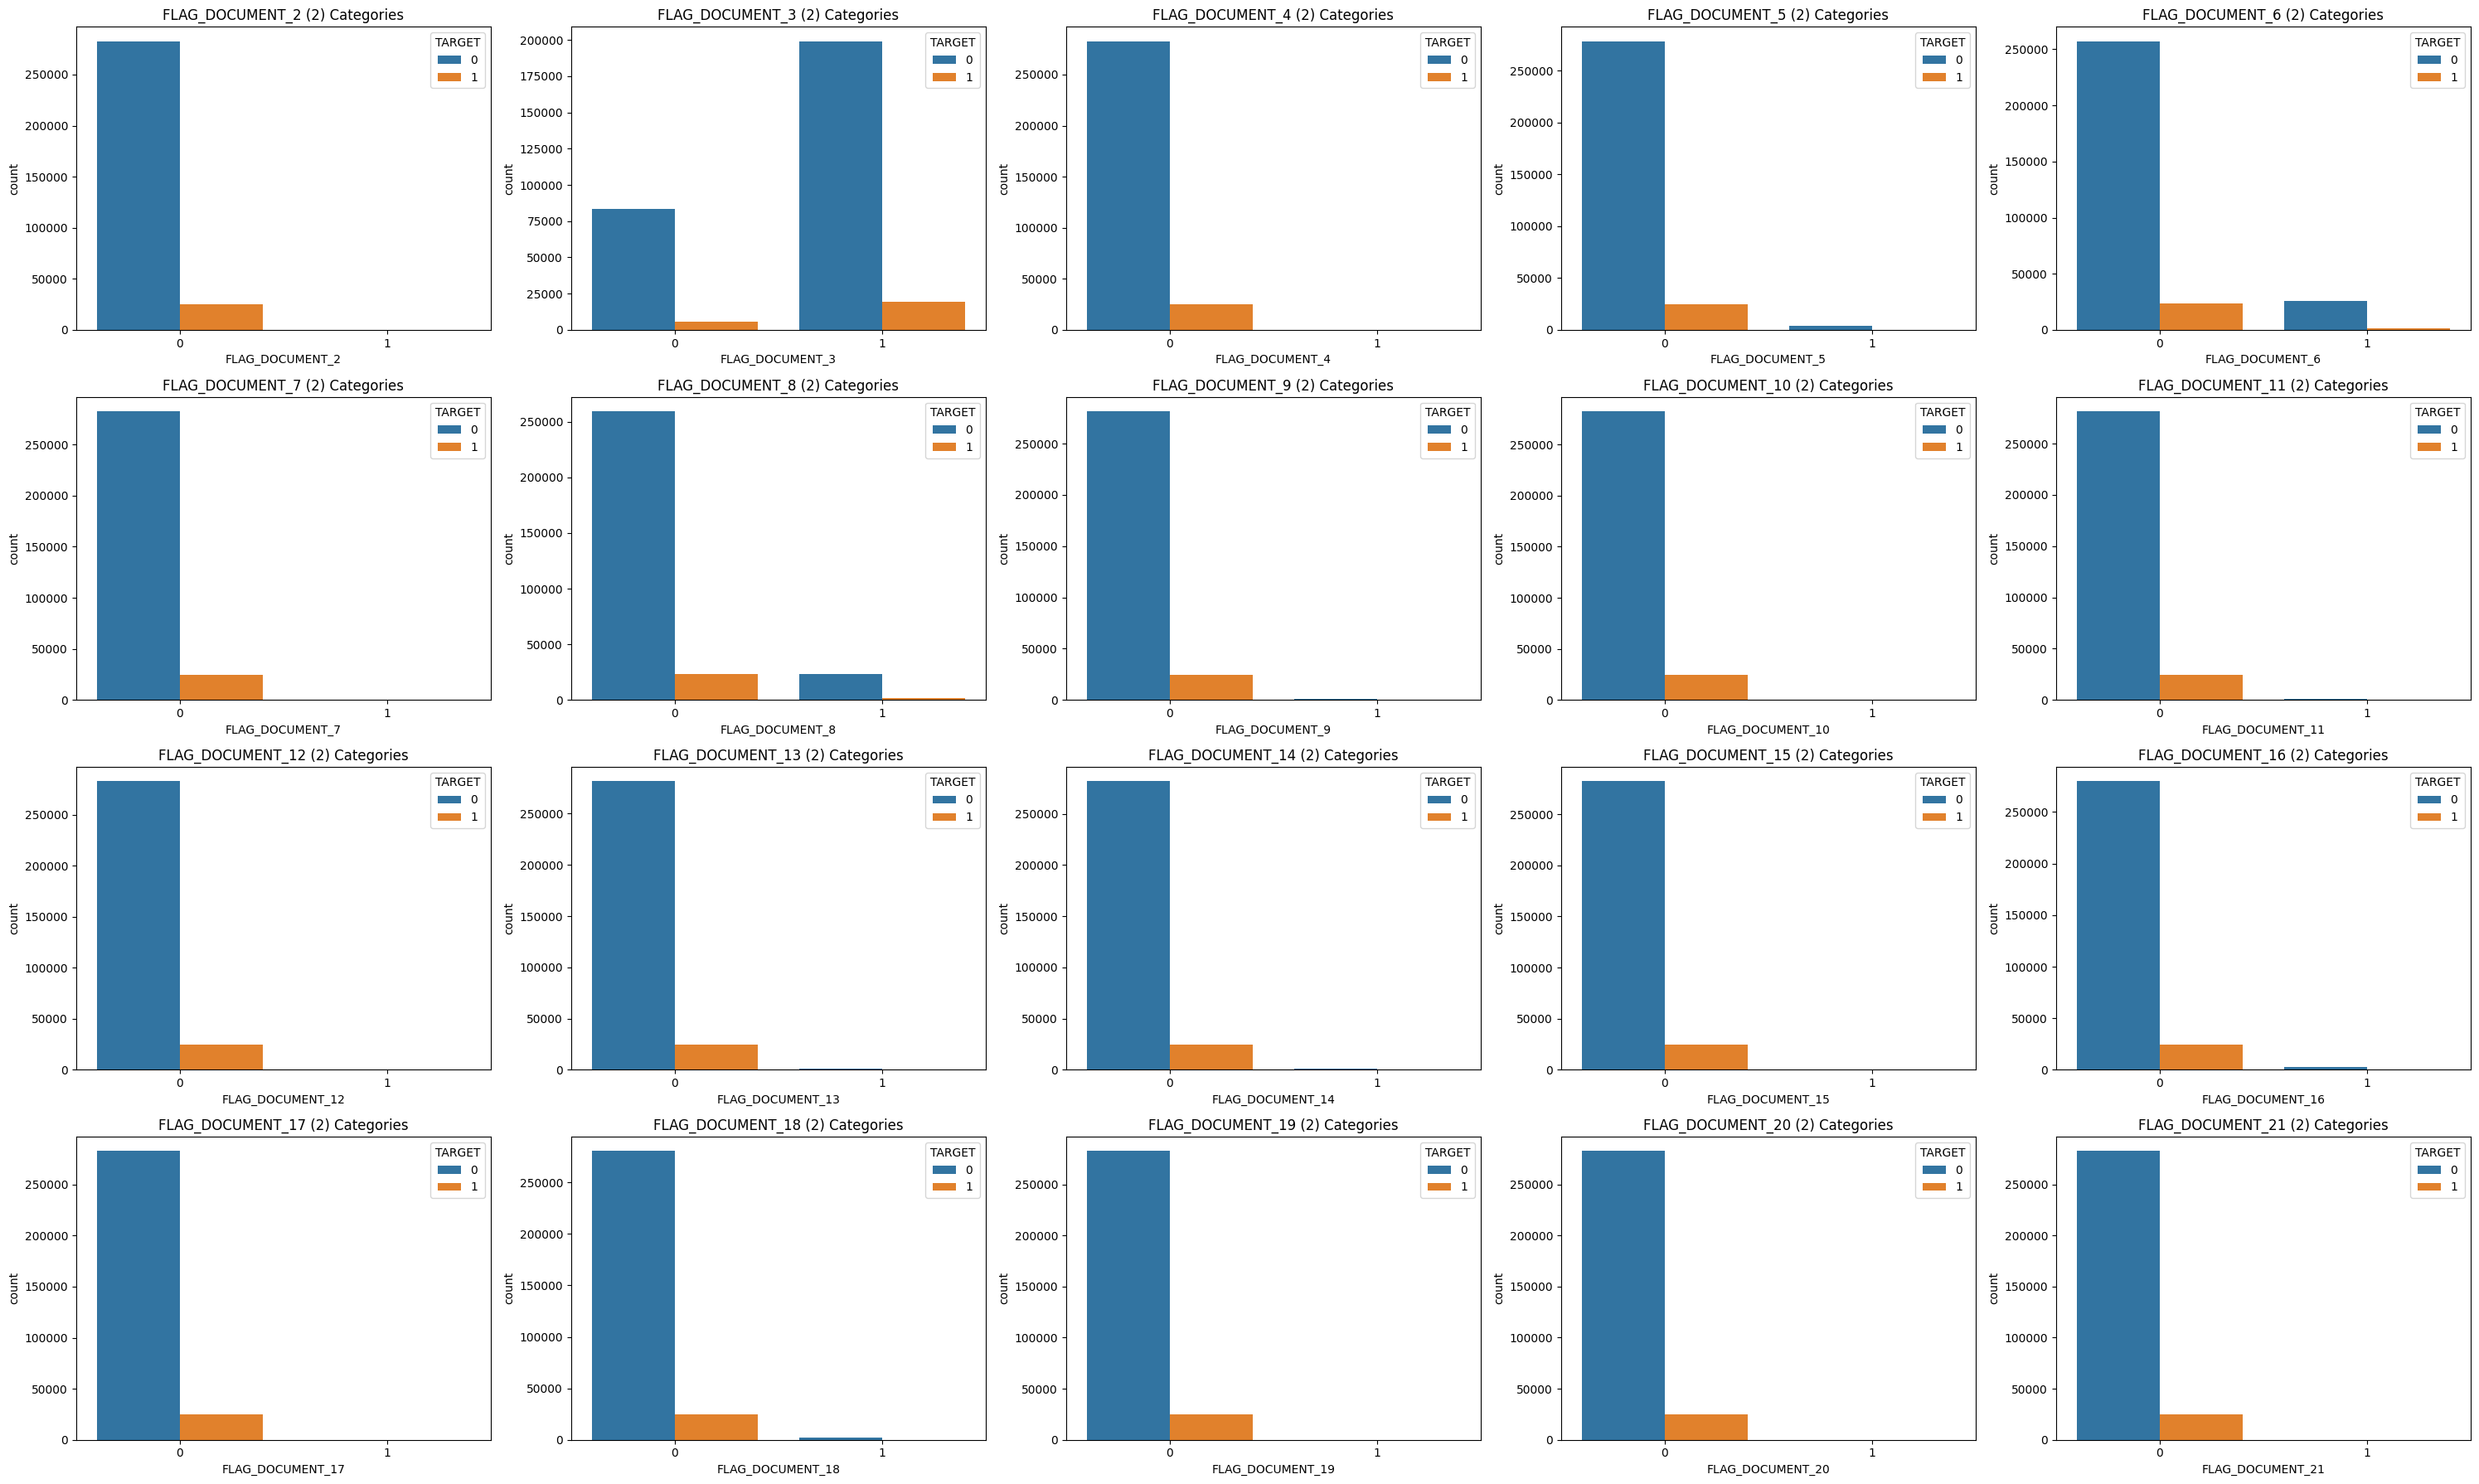

In [ ]:
plot_category_group(app, document_attr, target="TARGET", group_name="Document Attributes", n_cols=5)

### plotting proptional matrices for each categories

In [22]:
def plot_proportion_matrix_group(dataframe, col_list, target, group_name, n_cols = 2):

  """Fills missing values with 'UNK', slices high cardinality columns, and plots a grid
     of normalized target proportion matrices (heatmaps)"""
  print(f"\n" + "=" * 50)
  print(f"Proportional Matrices: {group_name.upper()}")
  print("=" * 50)

  #Handling missing value
  df_temp = dataframe.copy()
  df_temp[col_list] = df_temp[col_list].fillna("UNK")

  #calculating grid structure
  n_rows = math.ceil(len(col_list)/n_cols)

  #creating the grid
  fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 5))

  if len(col_list) == 1:
    axes = [axes]
  else:
    axes = axes.flatten()

  #loop and build matrices
  for i,col in enumerate(col_list):
    #cross tabulation calculation
    prop_matrix = pd.crosstab(
        index=df_temp[col], columns=df_temp[target], normalize='index'
    )

    #slicing down to top 10 categories by volume if its too large
    num_categories = df_temp[col].nunique()
    if num_categories > 10:
      top_15_cats = df_temp[col].value_counts().head(15).index
      prop_matrix = prop_matrix.loc[top_15_cats]
      title_suffix = f"(Top 15 Categories)"
    else:
      title_suffix = f"({num_categories} categories)"

    #plot proportional heatmap
    sns.heatmap(data=prop_matrix,
                annot=True,
                fmt =".1%",
                cmap="YlGnBu",
                linewidths=0.5,
                cbar=False,
                ax=axes[i],
                )
    axes[i].set_title(f"{col} Breakdown {title_suffix}", fontsize = 11)
    axes[i].set_ylabel("categories")
    axes[i].set_xlabel(f"{target} Class")

  #remove unused blank plots
  for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

  plt.tight_layout()
  plt.show()


Proportional Matrices: PERSONAL PROPORTIONS


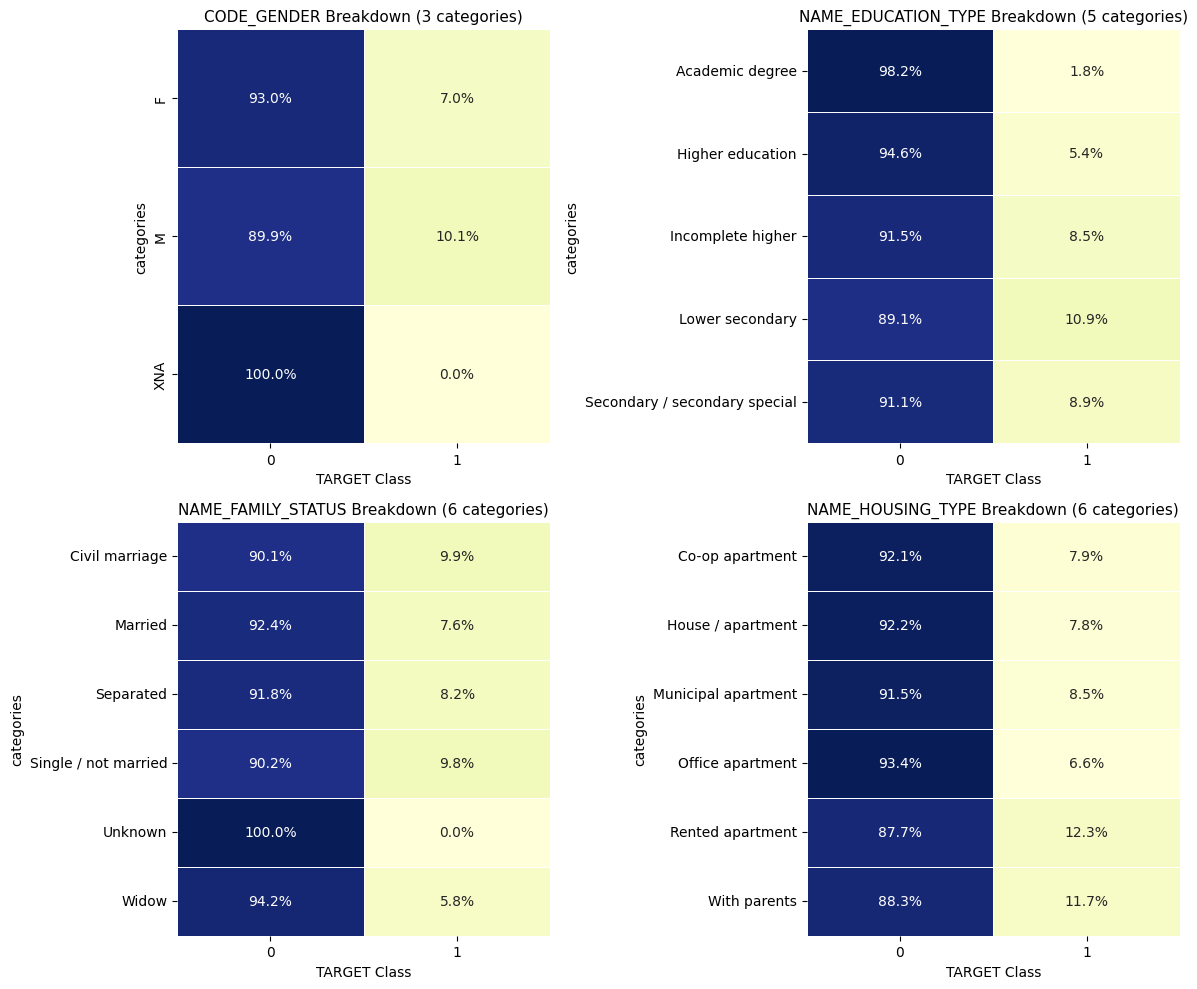

In [ ]:
plot_proportion_matrix_group(app, dem_attr, target='TARGET', group_name="Personal Proportions")


Proportional Matrices: EMPLOYMENT PROPORTIONS


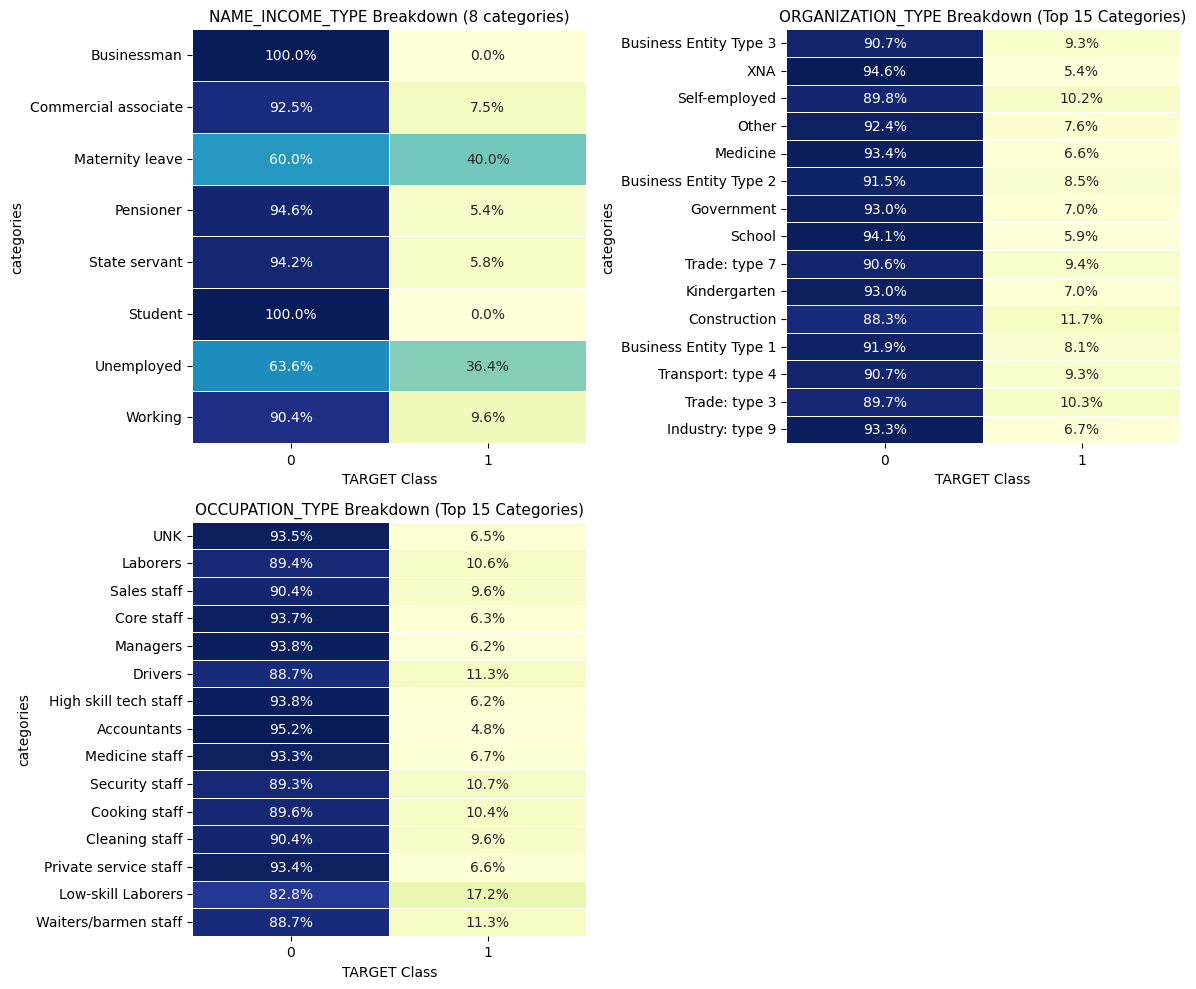

In [ ]:
plot_proportion_matrix_group(app, emp_attr, target='TARGET', group_name="Employment Proportions")


Proportional Matrices: LOAN PROPORTIONS


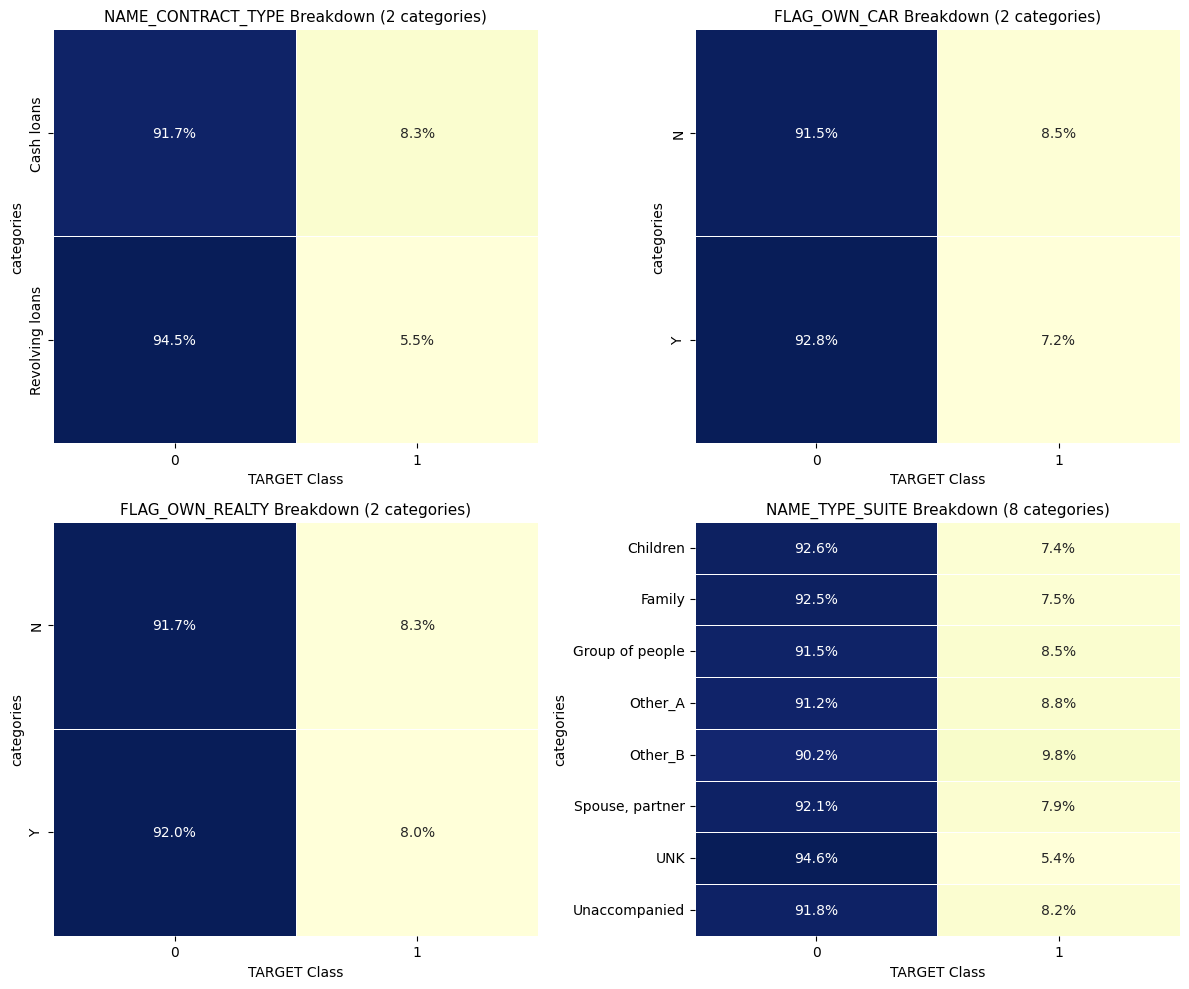

In [ ]:
plot_proportion_matrix_group(app, loan_attr, target='TARGET', group_name="Loan Proportions")


Proportional Matrices: CONT PROPORTIONS


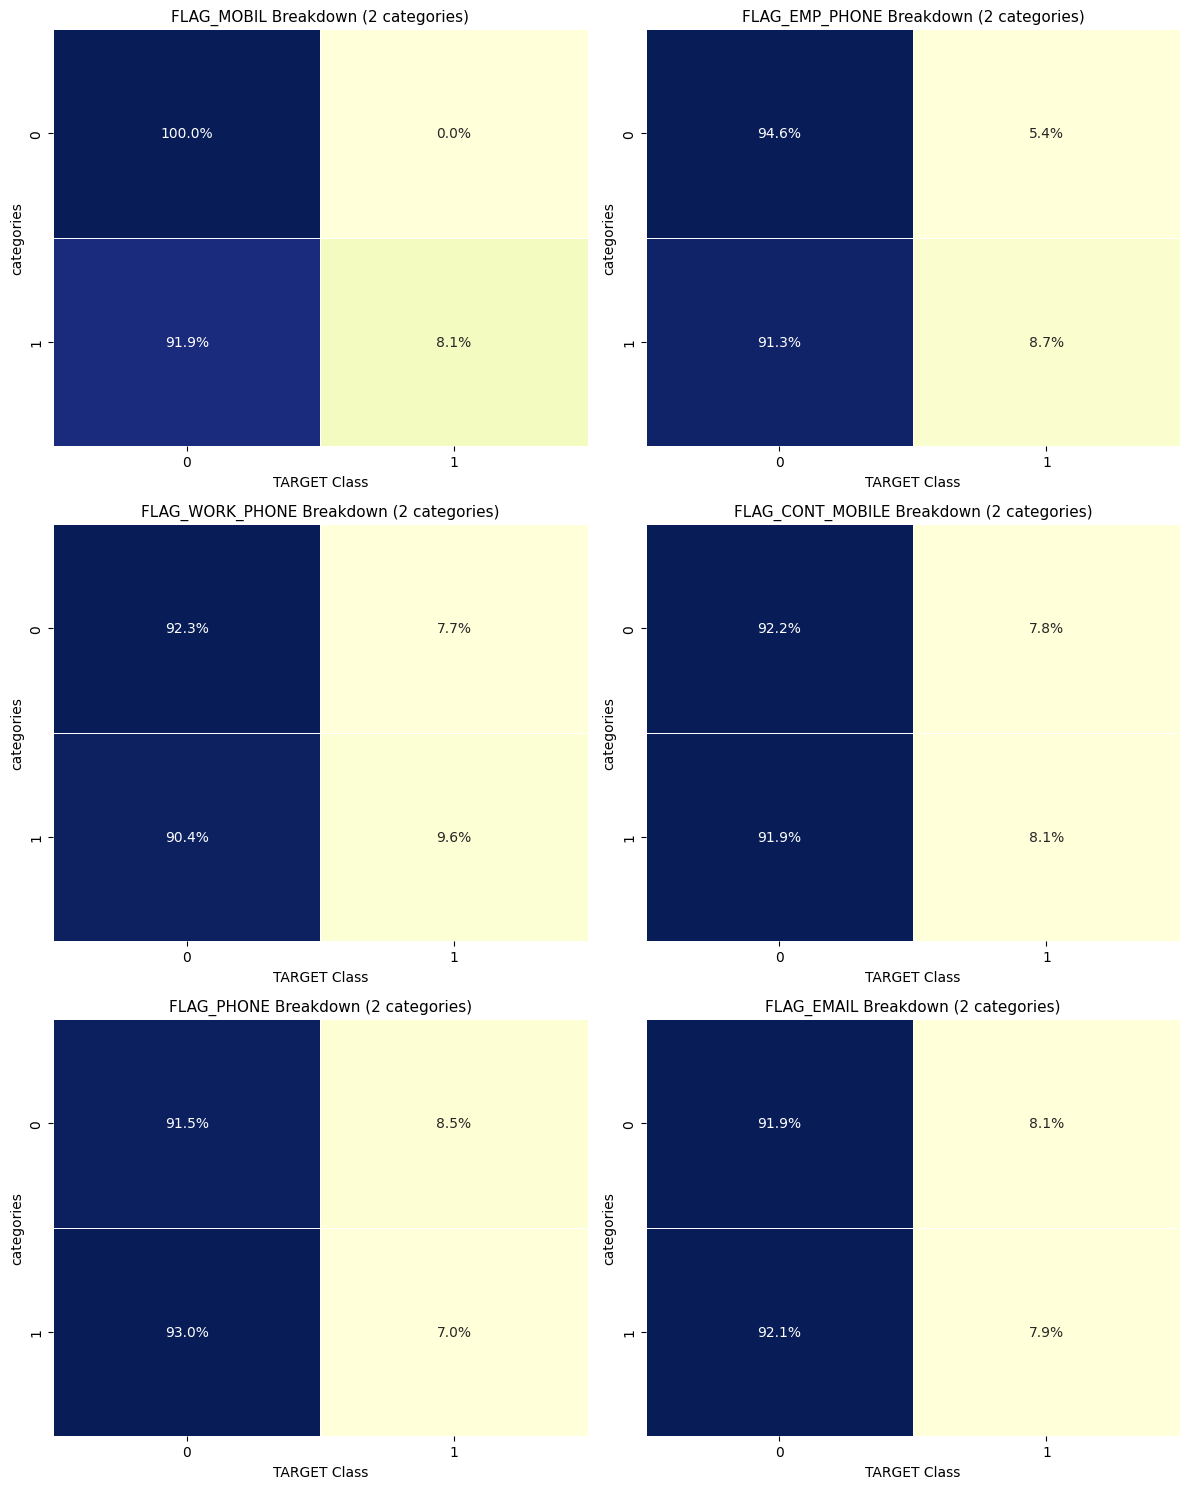

In [ ]:
plot_proportion_matrix_group(app, cont_attr, target='TARGET', group_name="cont Proportions")


Proportional Matrices: DOCUMENT PROPORTIONS


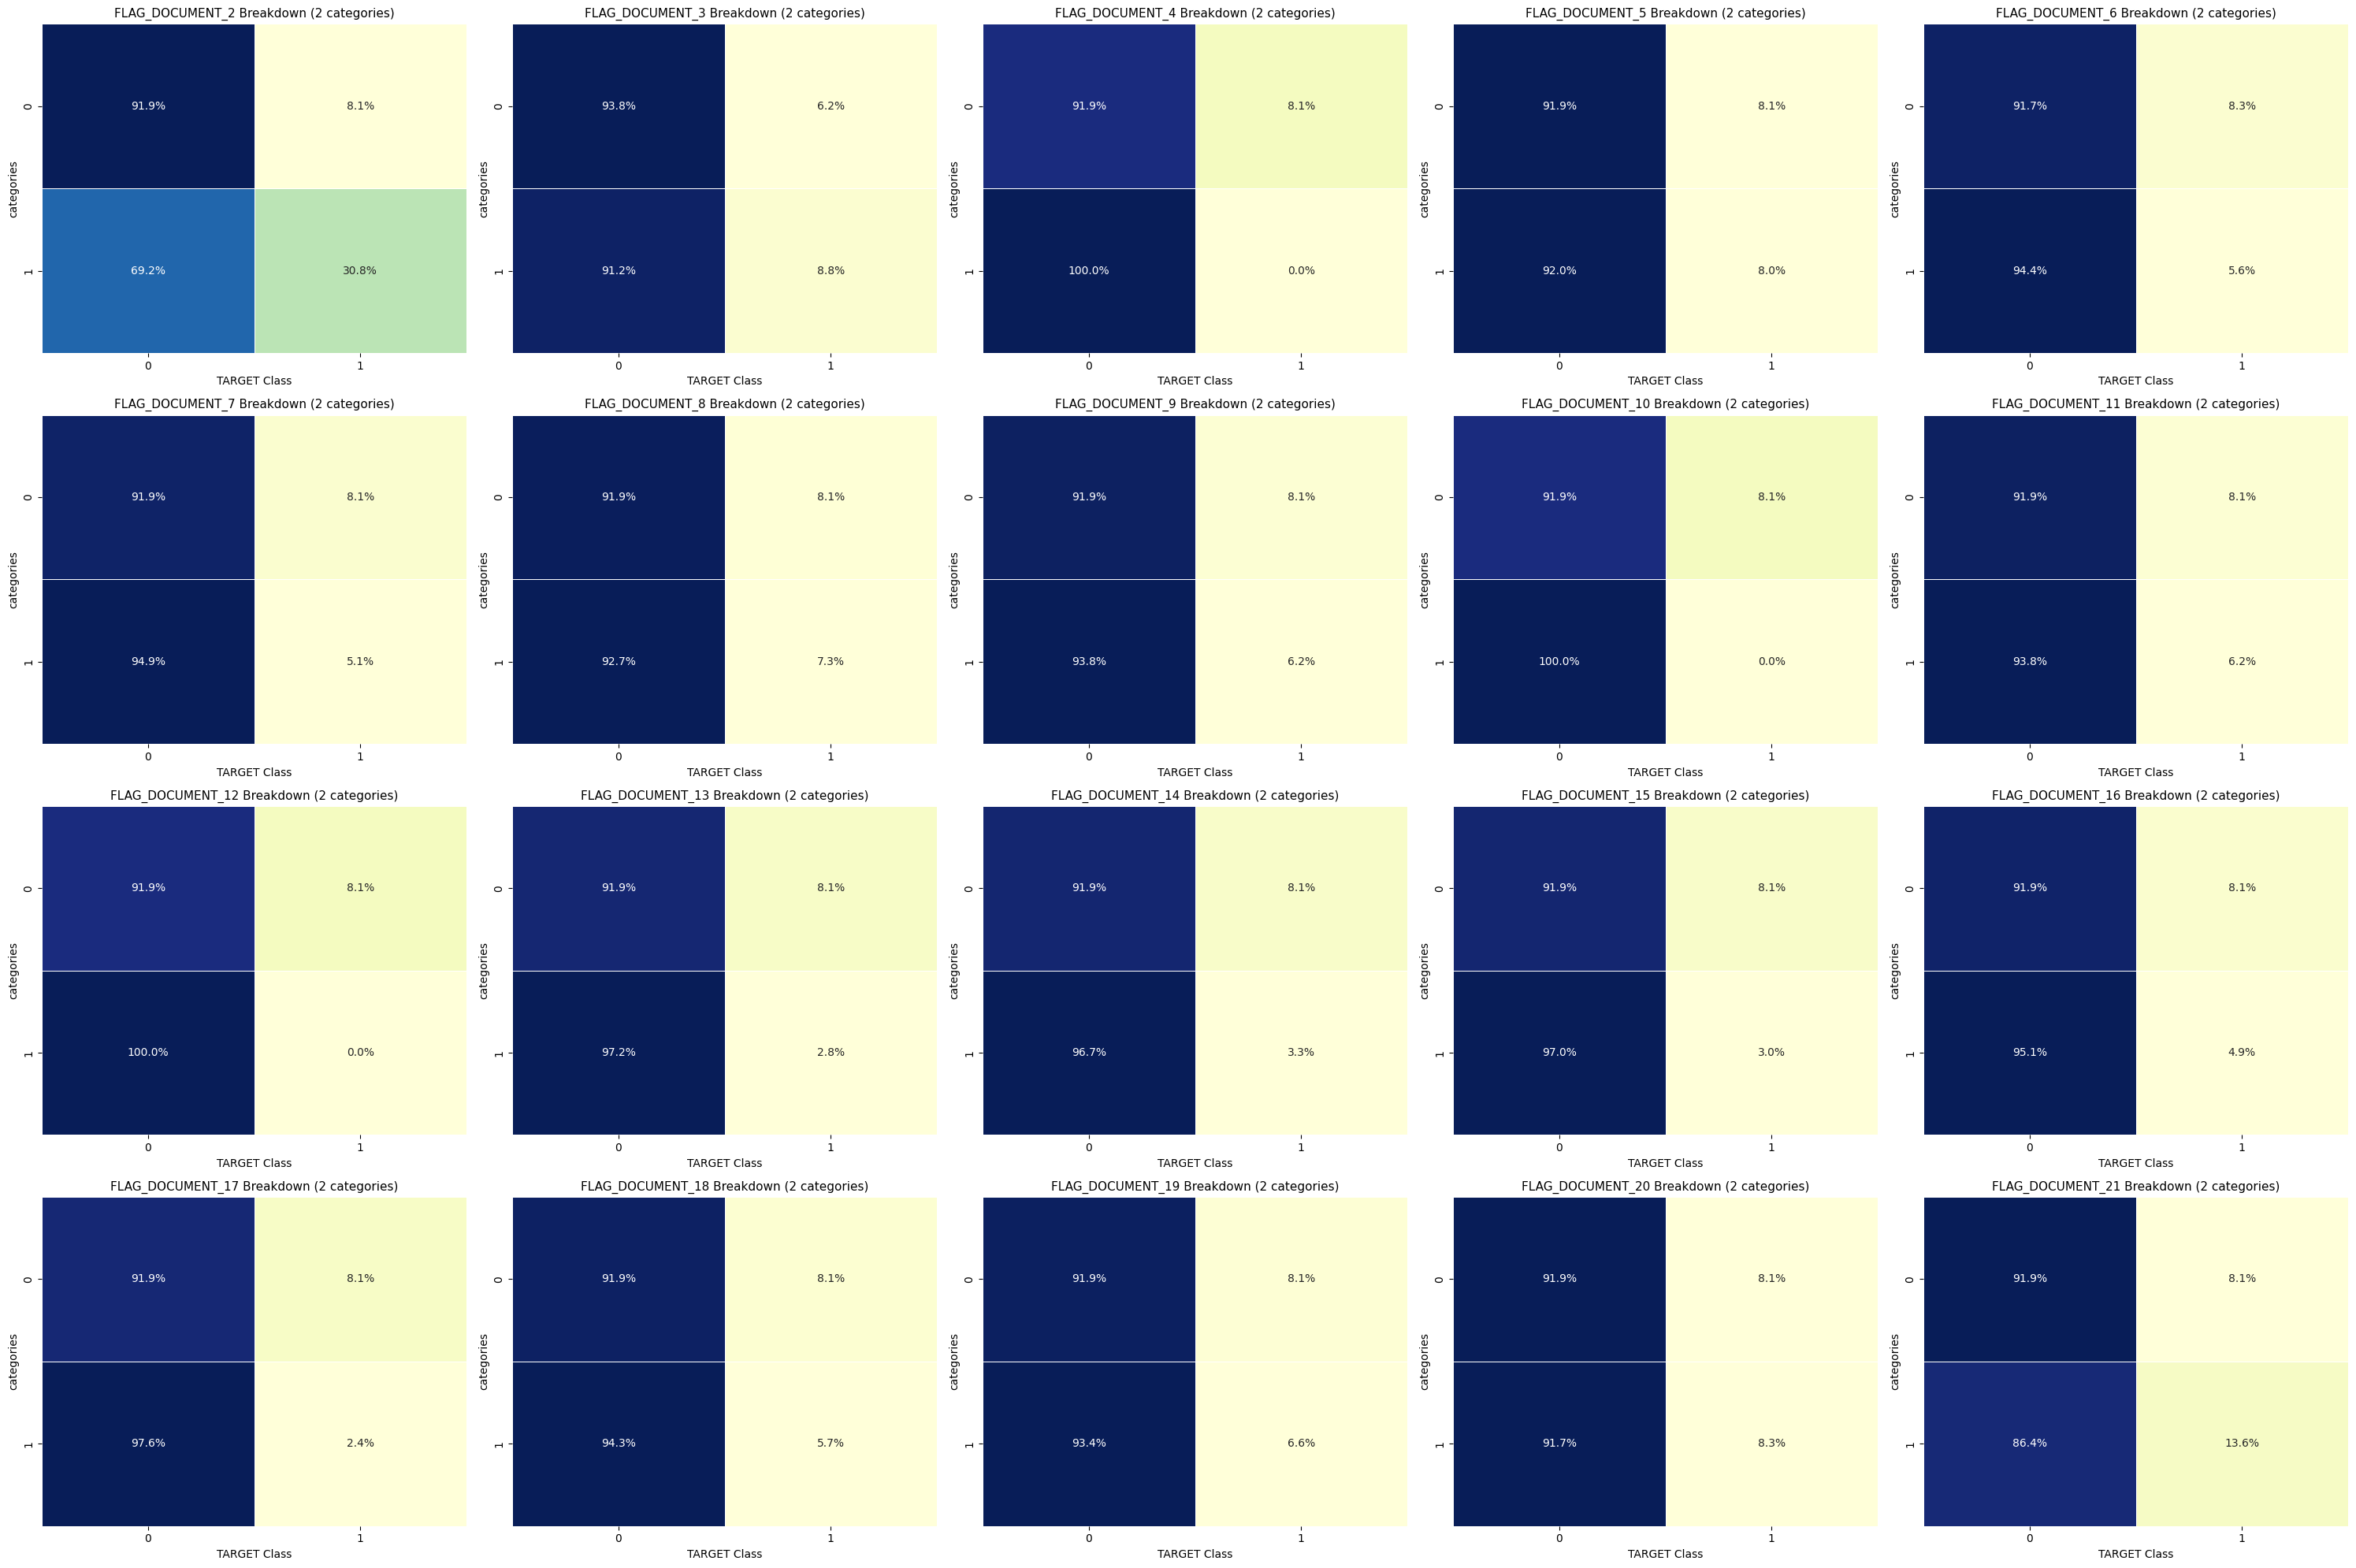

In [ ]:
plot_proportion_matrix_group(app, document_attr, target='TARGET', group_name="Document Proportions", n_cols=5)

### Working on Continuous variables  

In [23]:
#obtaining all numeric columns
numeric_cols = app.select_dtypes(include=[np.number]).columns.tolist()

In [24]:
len(numeric_cols)

51

In [25]:
#excluding the Target Variable
if "TARGET" in numeric_cols:
  numeric_cols.remove("TARGET")

In [26]:
#Separate Continous columns with binary flag
continuous_cols = []
binary_cols = []

for col in numeric_cols:
  if app[col].nunique() == 2:
    binary_cols.append(col)
  else:
    continuous_cols.append(col)

print(f"📊 Found {len(continuous_cols)} Truly Continuous Columns.")
print(f"🚩 Found {len(binary_cols)} Binary Flag Columns (0 and 1).")

📊 Found 18 Truly Continuous Columns.
🚩 Found 32 Binary Flag Columns (0 and 1).


In [27]:
continuous_cols

['SK_ID_CURR',
 'CNT_CHILDREN',
 'AMT_INCOME_TOTAL',
 'AMT_CREDIT',
 'AMT_ANNUITY',
 'AMT_GOODS_PRICE',
 'REGION_POPULATION_RELATIVE',
 'DAYS_BIRTH',
 'DAYS_EMPLOYED',
 'DAYS_REGISTRATION',
 'DAYS_ID_PUBLISH',
 'CNT_FAM_MEMBERS',
 'REGION_RATING_CLIENT',
 'REGION_RATING_CLIENT_W_CITY',
 'HOUR_APPR_PROCESS_START',
 'EXT_SOURCE_2',
 'EXT_SOURCE_3',
 'DAYS_LAST_PHONE_CHANGE']

In [28]:
#removing the SK_ID
continuous_cols.remove('SK_ID_CURR')

In [29]:
len(continuous_cols)

17

## Writing a function that plots box plots for all continuous variables, without handling outliers

In [30]:
def box_plot_grid(df, features, target, num_cols = 2):


  """generates a dynamic grid of boxplots hued by target variable
      optimized for large dataset with outliers"""

  num_features = len(features)
  num_rows = math.ceil(num_features/num_cols)

  #initialize matplotlib workspace
  fig, axes = plt.subplots(
      nrows=num_rows,
      ncols=num_cols,
      figsize=(num_cols * 5, num_rows * 4)
  )

  #handling edge cases
  if num_features == 1:
    axes = [axes]
  else:
    axes = axes.flatten()

  #looping through features and generating boxplots
  for i, col in enumerate(features):
    sns.boxplot(
        data=df,
        x=target,
        y=col,
        ax=axes[i],
        palette="Set2",
        legend=False,
        flierprops={'marker': 'o', 'alpha': 0.3, 'markersize': 3,},
    )
    axes[i].set_title(f"outlier distribution for {col}", fontsize=12, pad =10)
    axes[i].set_xlabel(f"{target}", fontsize=10)
    axes[i].set_ylabel("Value", fontsize=10)
    axes[i].grid(axis="y", linestyle='--', alpha=0.7)

  #removing unused blank plots
  for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

  plt.tight_layout()
  plt.show()

/tmp/ipykernel_1433/4012015848.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1433/4012015848.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1433/4012015848.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1433/4012015848.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1433/4012015848.py:25: FutureWarning: 

P

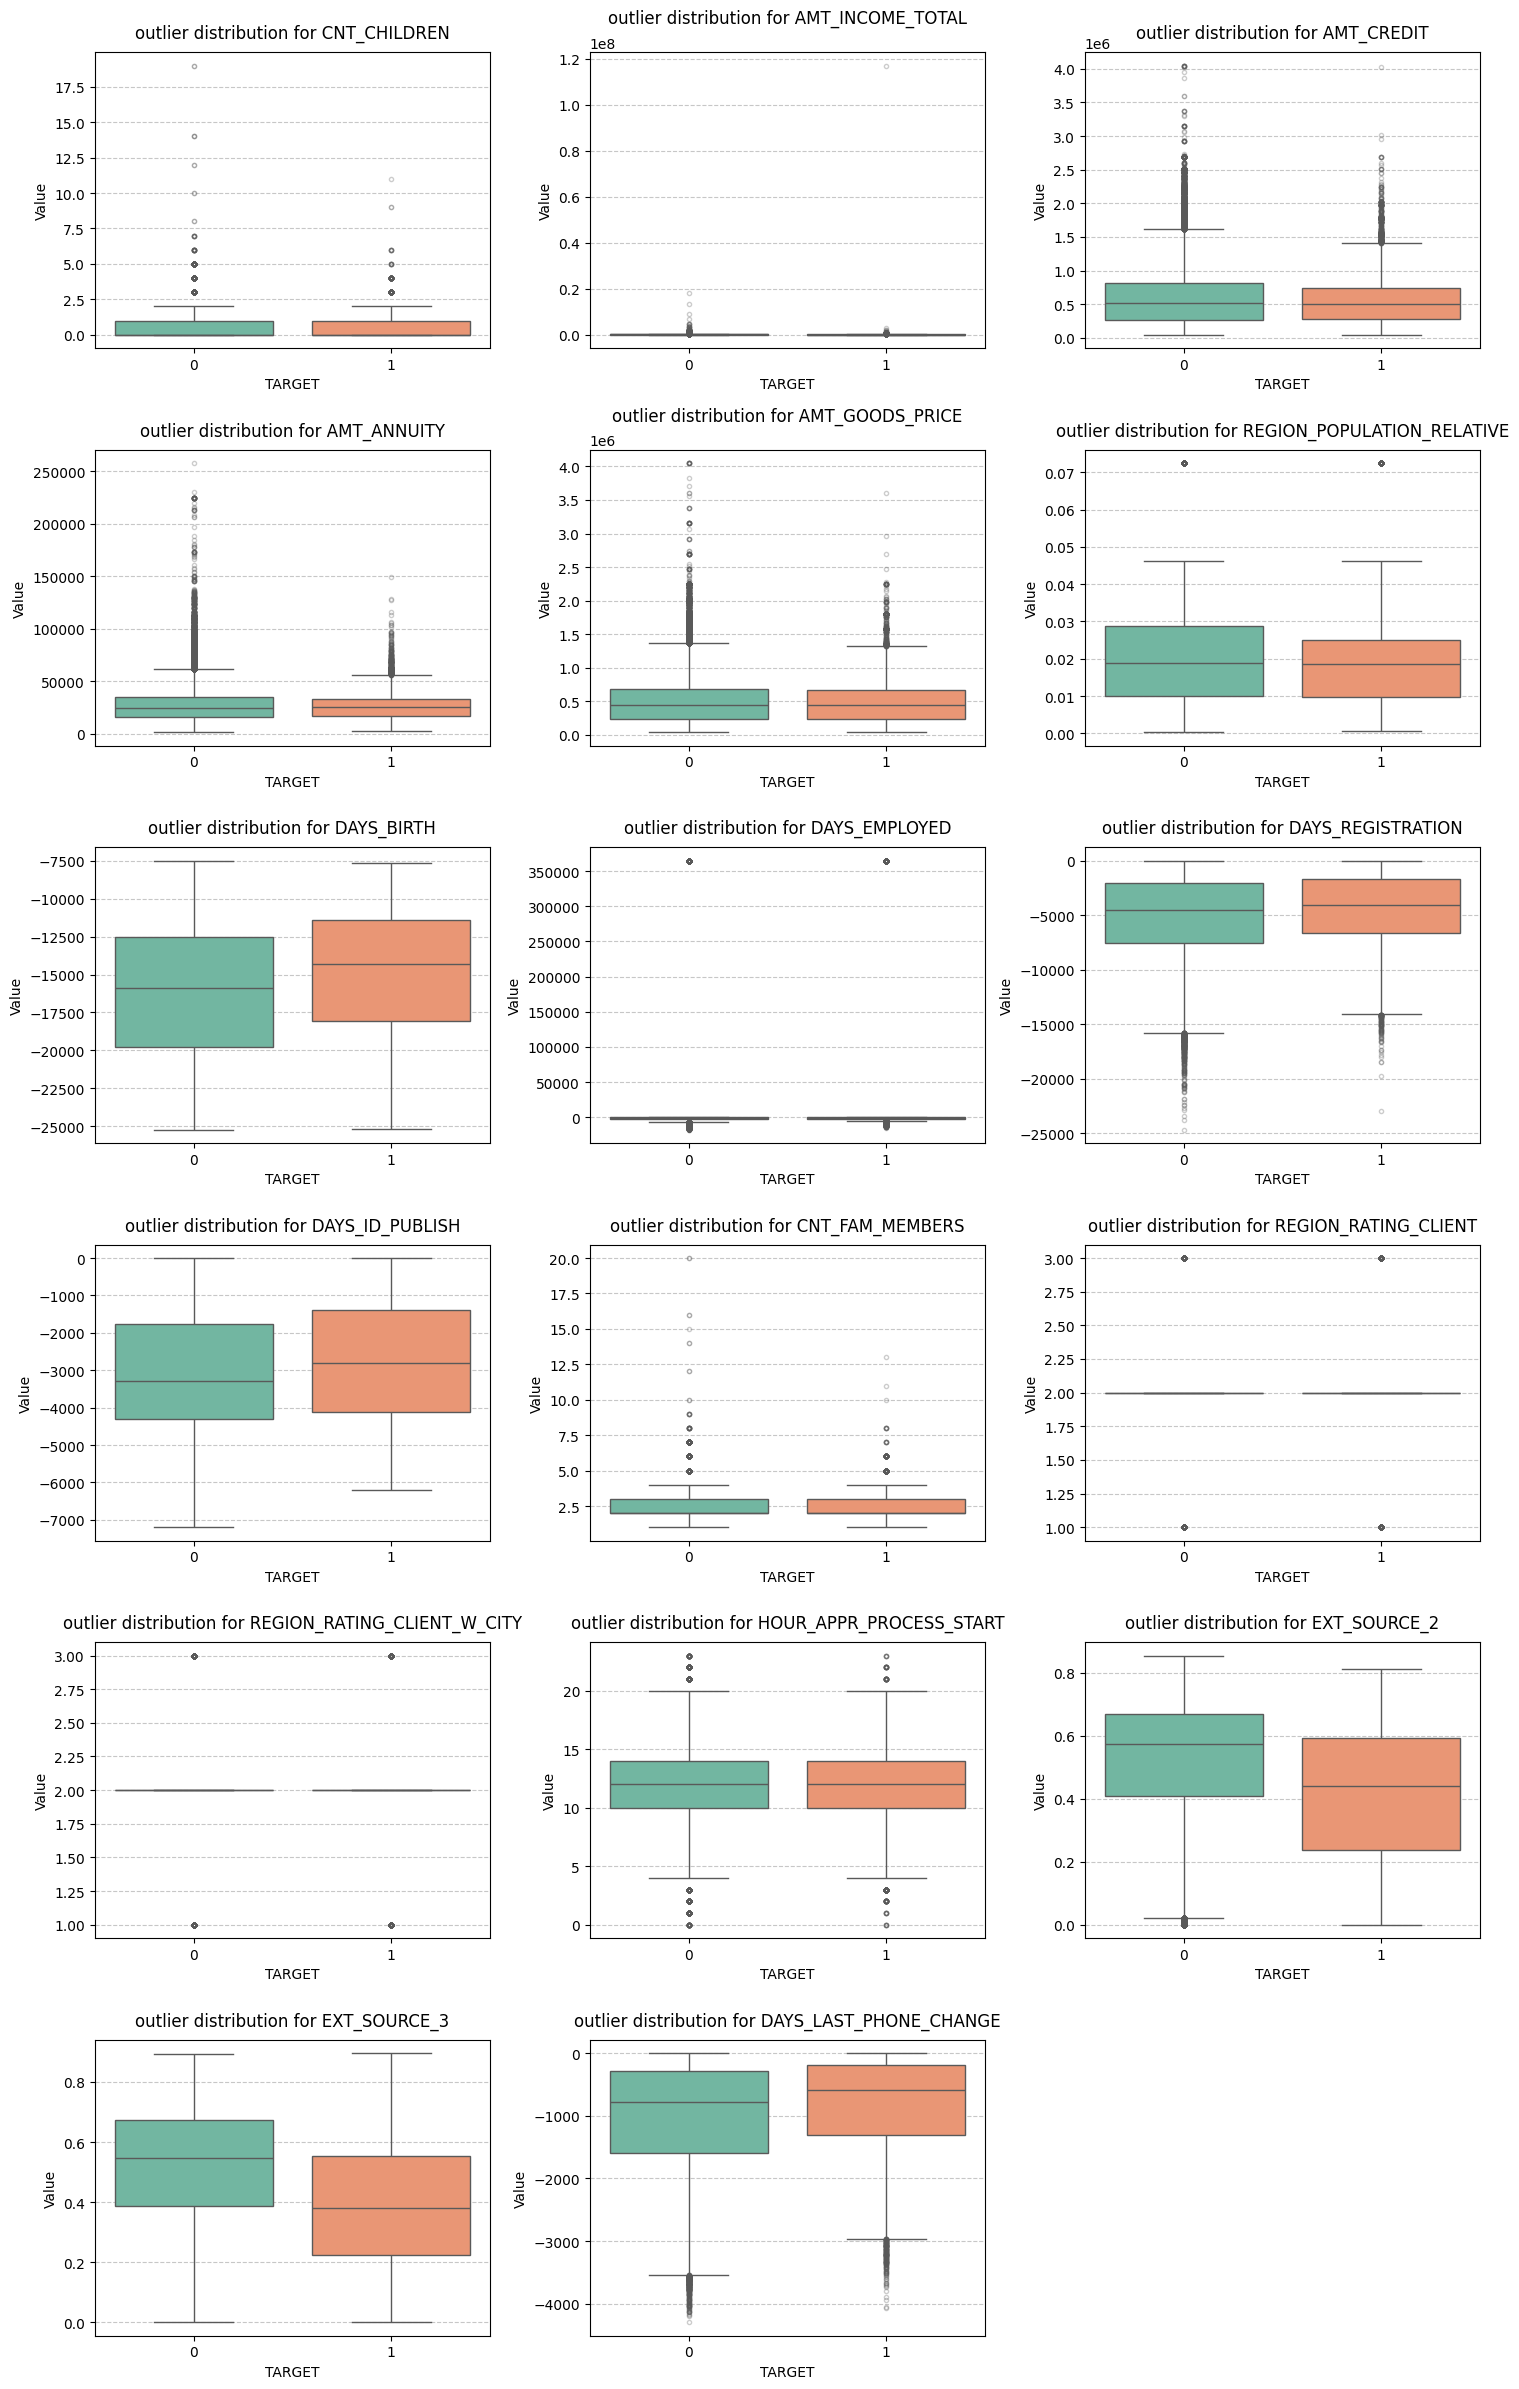

In [ ]:
box_plot_grid(app, continuous_cols, target="TARGET", num_cols=3)

In [ ]:
np.median(app['AMT_INCOME_TOTAL'])

np.float64(147150.0)

## Replacing outliers with median

In [31]:
def handle_outliers_with_median(df, columns, inplace=False):
    """Identifies outliers using the IQR method (1.5 * IQR) and replaces them

    with the column's median value. Capable of handling single or multiple
    columns.
    """
    # 1. Create a copy if not modifying in place to prevent SettingWithCopyWarning
    working_df = df if inplace else df.copy()

    # 2. Standardise input to handle both a single string or a list of columns
    if isinstance(columns, str):
        columns = [columns]

    # 3. Process each column systematically
    for column in columns:
        if column not in working_df.columns:
            print(f" Warning: '{column}' not found in DataFrame. Skipping.")
            continue

        # Calculate IQR boundaries
        Q1 = working_df[column].quantile(0.25)
        Q3 = working_df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Calculate median value of the specific column
        median_val = working_df[column].median()

        # Replace extreme anomalies with the median value
        working_df[column] = np.where(
            (working_df[column] < lower_bound)
            | (working_df[column] > upper_bound),
            median_val,
            working_df[column],
        )

    return working_df


In [32]:
app_cleaned = handle_outliers_with_median(app, continuous_cols)

/tmp/ipykernel_1433/4012015848.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1433/4012015848.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1433/4012015848.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1433/4012015848.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1433/4012015848.py:25: FutureWarning: 

P

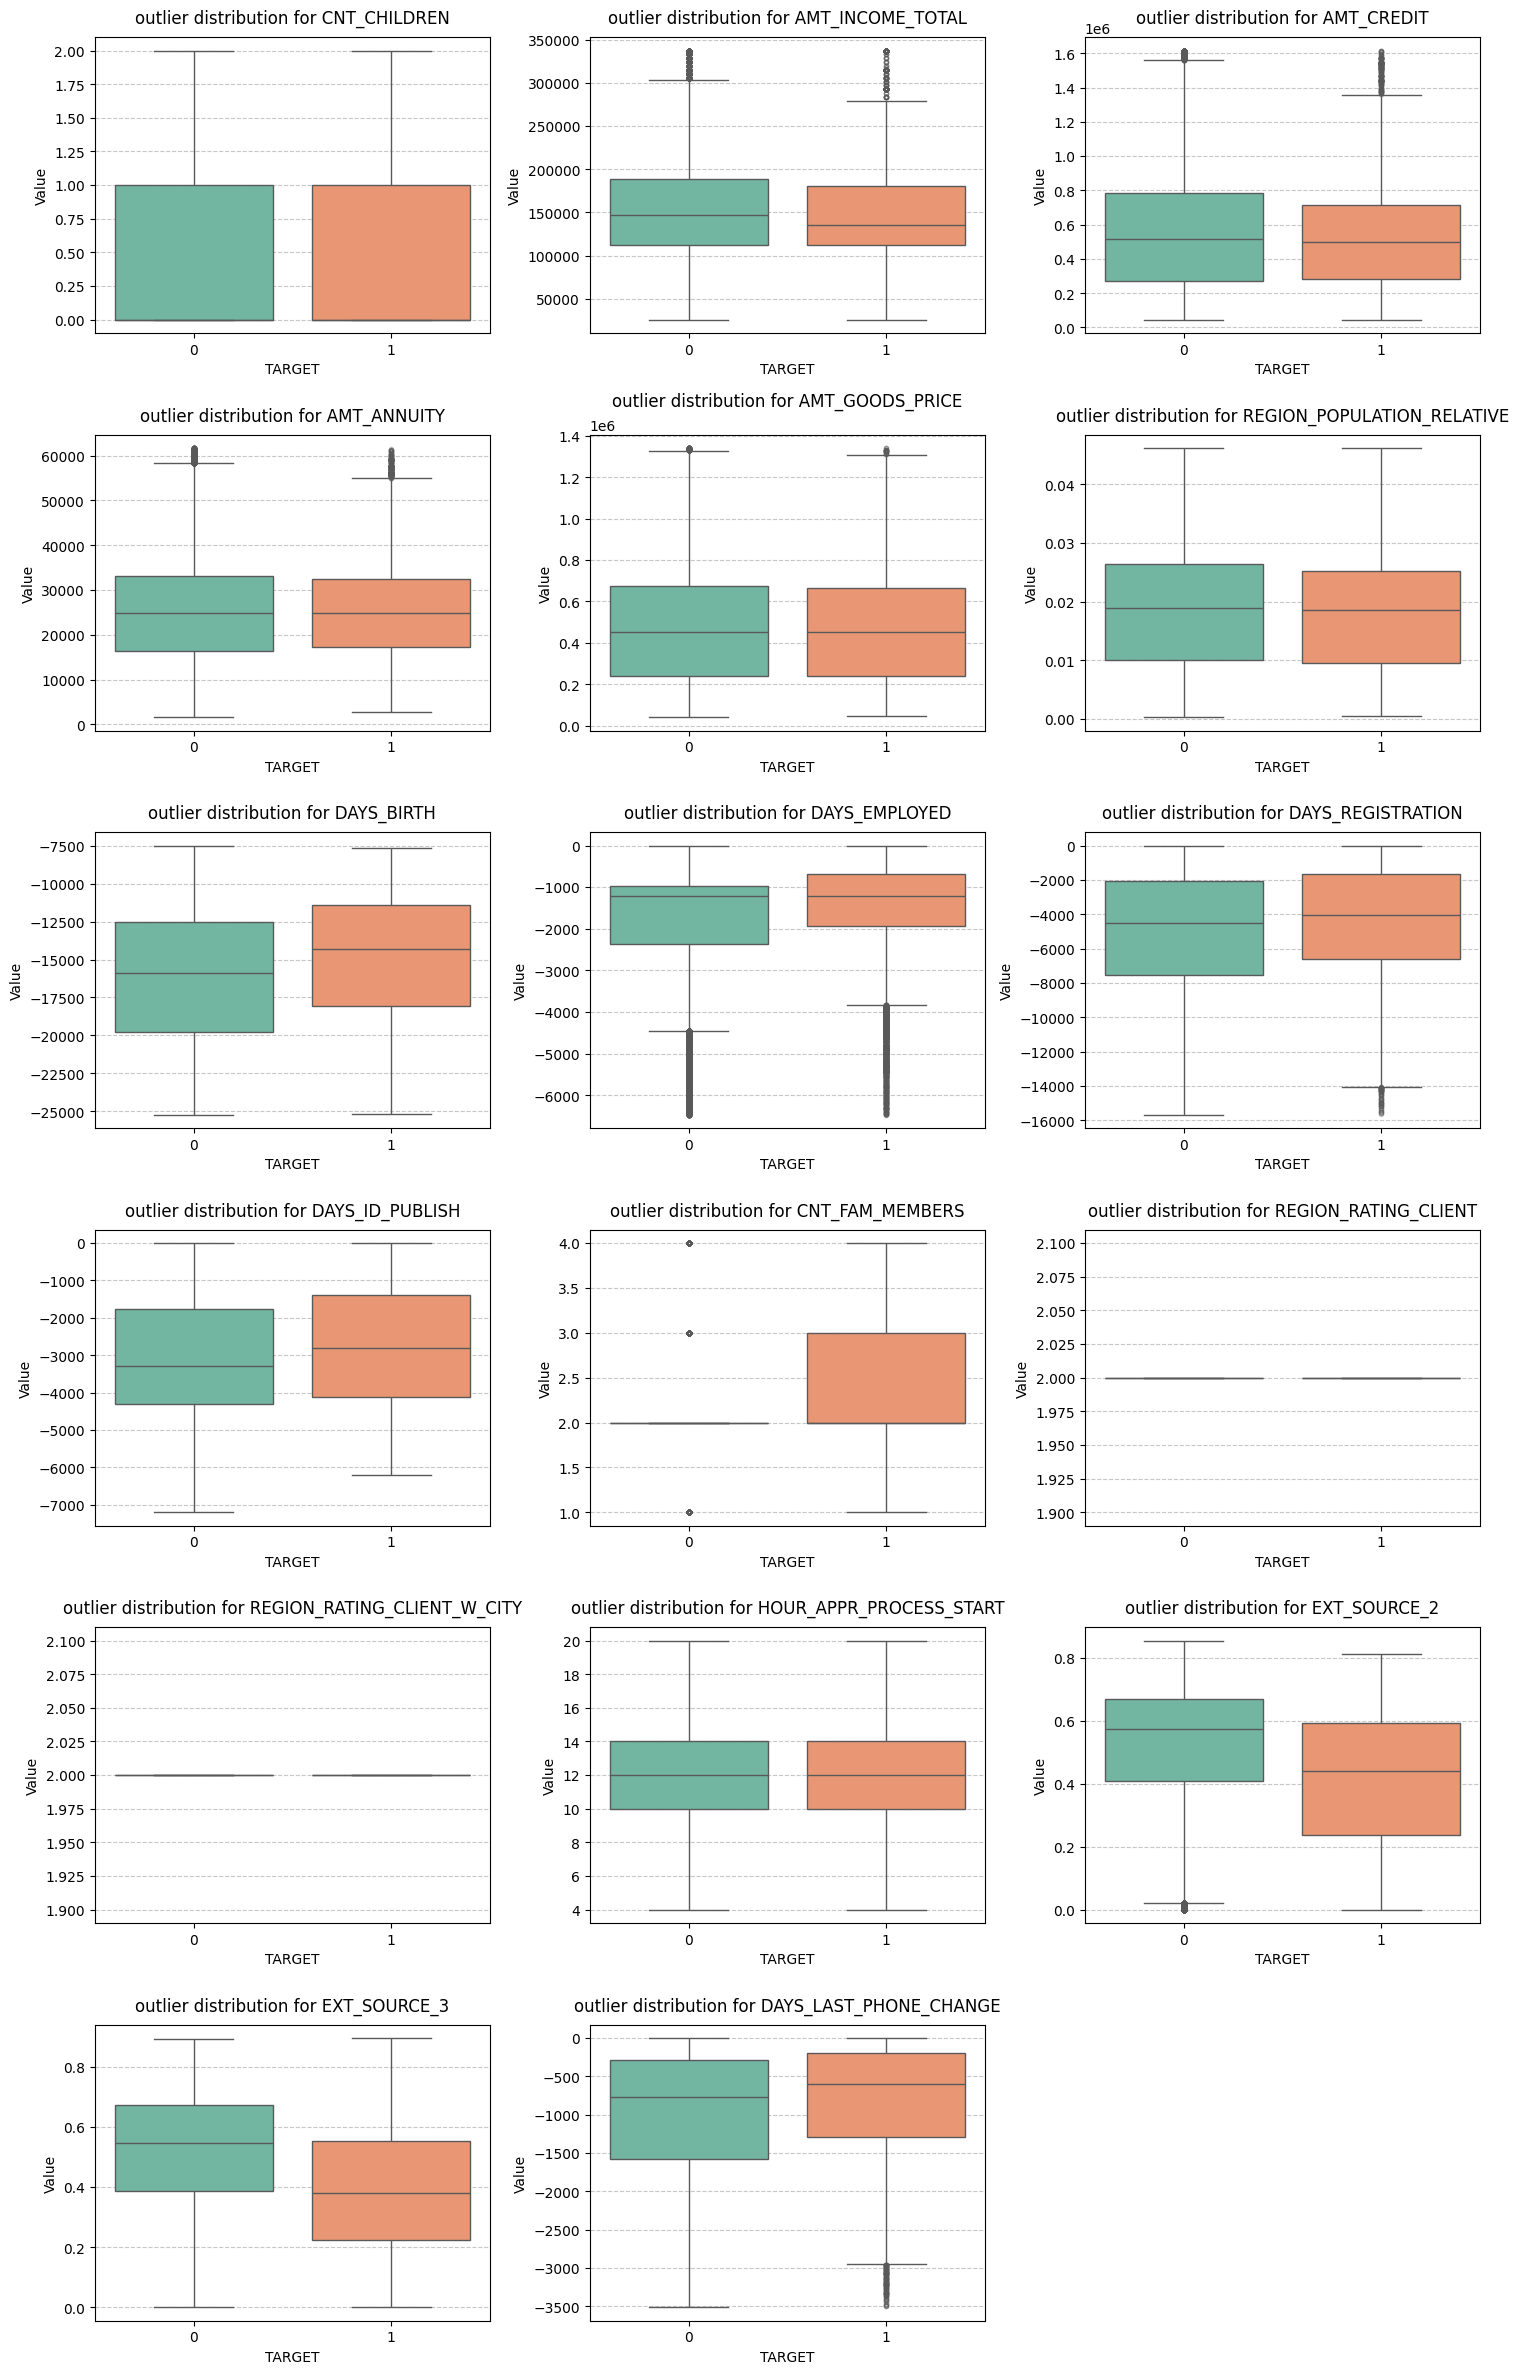

In [ ]:
box_plot_grid(app_cleaned, continuous_cols, target = "TARGET", num_cols=3)

In [33]:
app_cleaned0 = app_cleaned[app_cleaned['TARGET'] == 0]
app_cleaned1 = app_cleaned[app_cleaned['TARGET'] == 1]

In [34]:
app_cleaned1.shape

(24825, 63)

In [35]:
corr0_matrix = app_cleaned0[continuous_cols].corr()
corr1_matrix = app_cleaned1[continuous_cols].corr()

### A function to extract top n correlations

In [36]:
def plot_top_correlations_with_heatmap(corr_matrix, n_top_correlations=10):
    """Analyzes a correlation matrix to find top N absolute correlations and plots them
    alongside the full heatmap for better legibility.

    Args:
        corr_matrix (pd.DataFrame): The input correlation matrix.
        n_top_correlations (int): The number of top absolute correlations to display.
    """

    # Unstack the correlation matrix to a series
    corr_series = corr_matrix.unstack()

    # Drop NaN values (correlations that couldn't be computed, e.g., if a column is constant)
    corr_series = corr_series.dropna()

    # Filter out self-correlations (e.g., 'feature_A' with 'feature_A')
    corr_series = corr_series[corr_series.index.get_level_values(0) != corr_series.index.get_level_values(1)]

    # Remove duplicate pairs (e.g., if A-B is present, remove B-A)
    # We create a frozenset of the two feature names to identify unique pairs regardless of order
    corr_series_unique_pairs = corr_series.loc[~corr_series.index.map(frozenset).duplicated()]

    # Sort by absolute value to find the strongest correlations
    top_absolute_correlations_series = corr_series_unique_pairs.abs().sort_values(ascending=False)

    # Select the top N absolute correlations indices
    top_correlations_indices = top_absolute_correlations_series.head(n_top_correlations).index

    # Get the actual correlation values for these top indices from the unique pairs series
    top_correlations_df = corr_series_unique_pairs.loc[top_correlations_indices].to_frame(name='Correlation').reset_index()
    top_correlations_df.columns = ['Feature_1', 'Feature_2', 'Correlation']

    print(f"Top {n_top_correlations} Correlations (absolute value):")
    display(top_correlations_df)

    # Create a figure with two subplots for the heatmap and the bar plot
    fig, axes = plt.subplots(1, 2, figsize=(20, 8)) # Adjusted figsize for better readability

    # Plot 1: Full Heatmap of the correlation matrix
    # Fill NaN values in the correlation matrix with 0 for display in the heatmap
    corr_matrix_for_heatmap = corr_matrix.fillna(0)
    sns.heatmap(corr_matrix_for_heatmap, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                square=True, ax=axes[0], cbar_kws={'label': 'Correlation'})
    axes[0].set_title('Full Correlation Matrix Heatmap', fontsize=14)
    axes[0].tick_params(axis='x', rotation=90)
    axes[0].tick_params(axis='y', rotation=0)

    # Plot 2: Bar plot of Top N Correlations
    sns.barplot(x='Correlation', y=top_correlations_df['Feature_1'] + ' vs ' + top_correlations_df['Feature_2'],
                data=top_correlations_df, palette='viridis', ax=axes[1])
    axes[1].set_title(f'Top {n_top_correlations} Correlations (Absolute Value)', fontsize=14)
    axes[1].set_xlabel('Correlation Coefficient', fontsize=12)
    axes[1].set_ylabel('Feature Pair', fontsize=12)
    axes[1].tick_params(axis='x', labelsize=10)
    axes[1].tick_params(axis='y', labelsize=10)

    plt.tight_layout()
    plt.show()


Top 6 Correlations (absolute value):


,Feature_1,Feature_2,Correlation
0,AMT_CREDIT,AMT_GOODS_PRICE,0.915150
1,CNT_CHILDREN,CNT_FAM_MEMBERS,0.852678
2,AMT_CREDIT,AMT_ANNUITY,0.723462
3,AMT_ANNUITY,AMT_GOODS_PRICE,0.700295
4,AMT_INCOME_TOTAL,AMT_ANNUITY,0.378921
5,AMT_INCOME_TOTAL,AMT_CREDIT,0.306271


/tmp/ipykernel_830/3508856293.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Correlation', y=top_correlations_df['Feature_1'] + ' vs ' + top_correlations_df['Feature_2'],


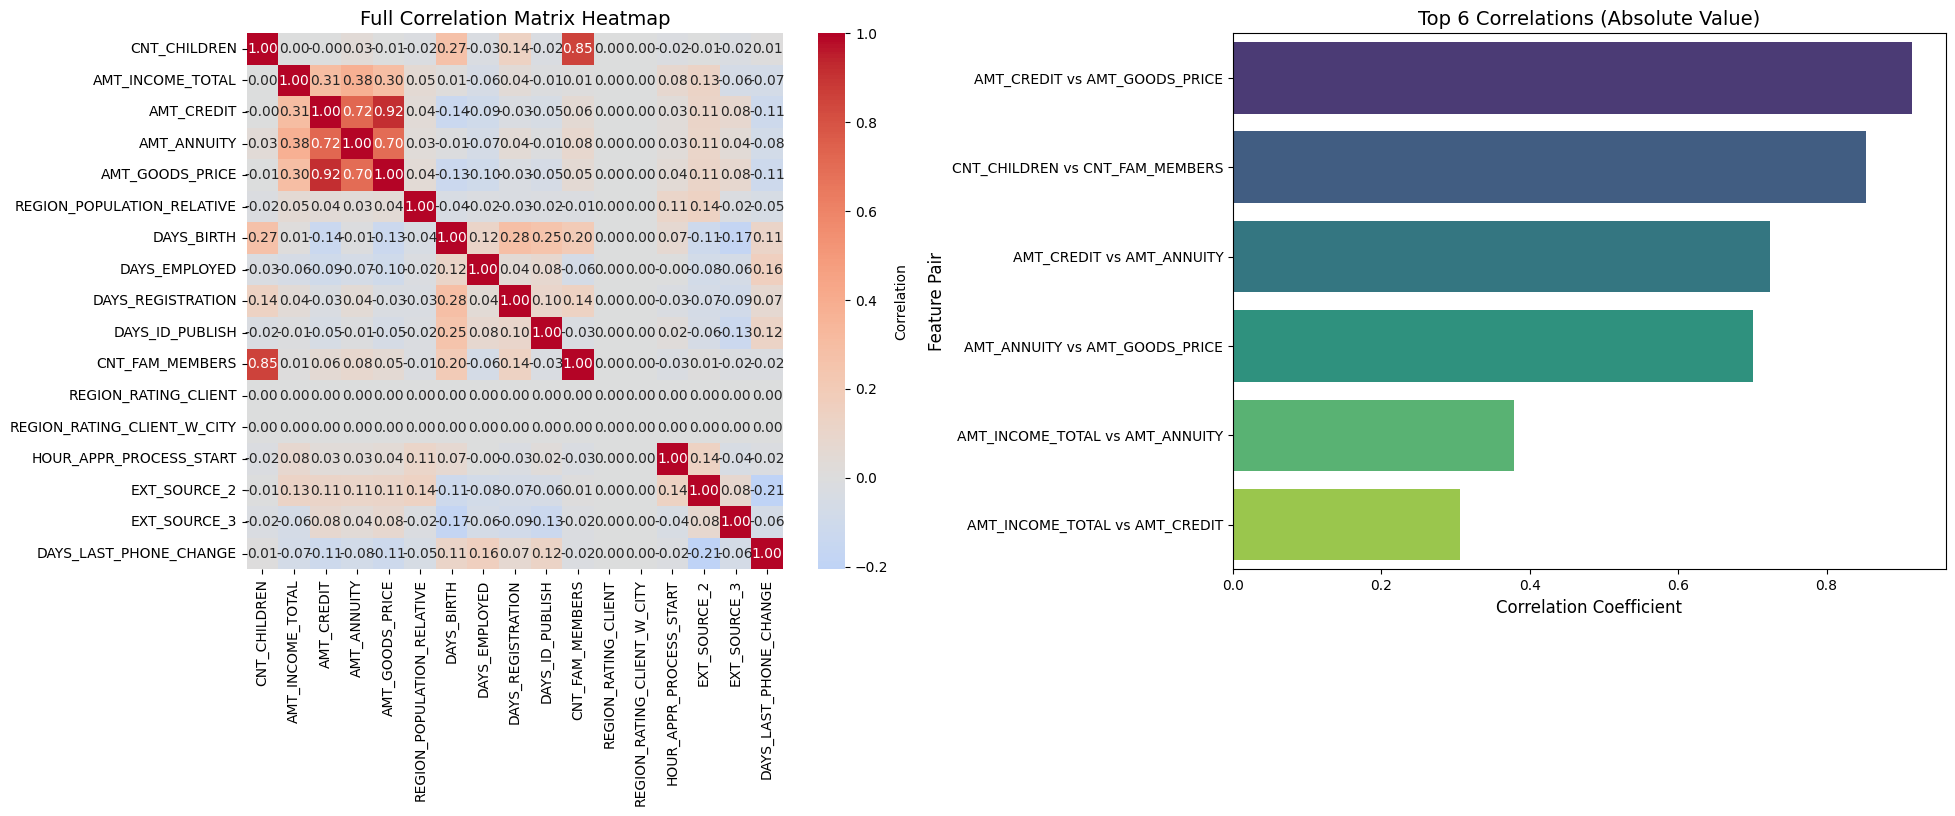

In [ ]:
# Use the newly defined function
plot_top_correlations_with_heatmap(corr1_matrix, n_top_correlations=6)

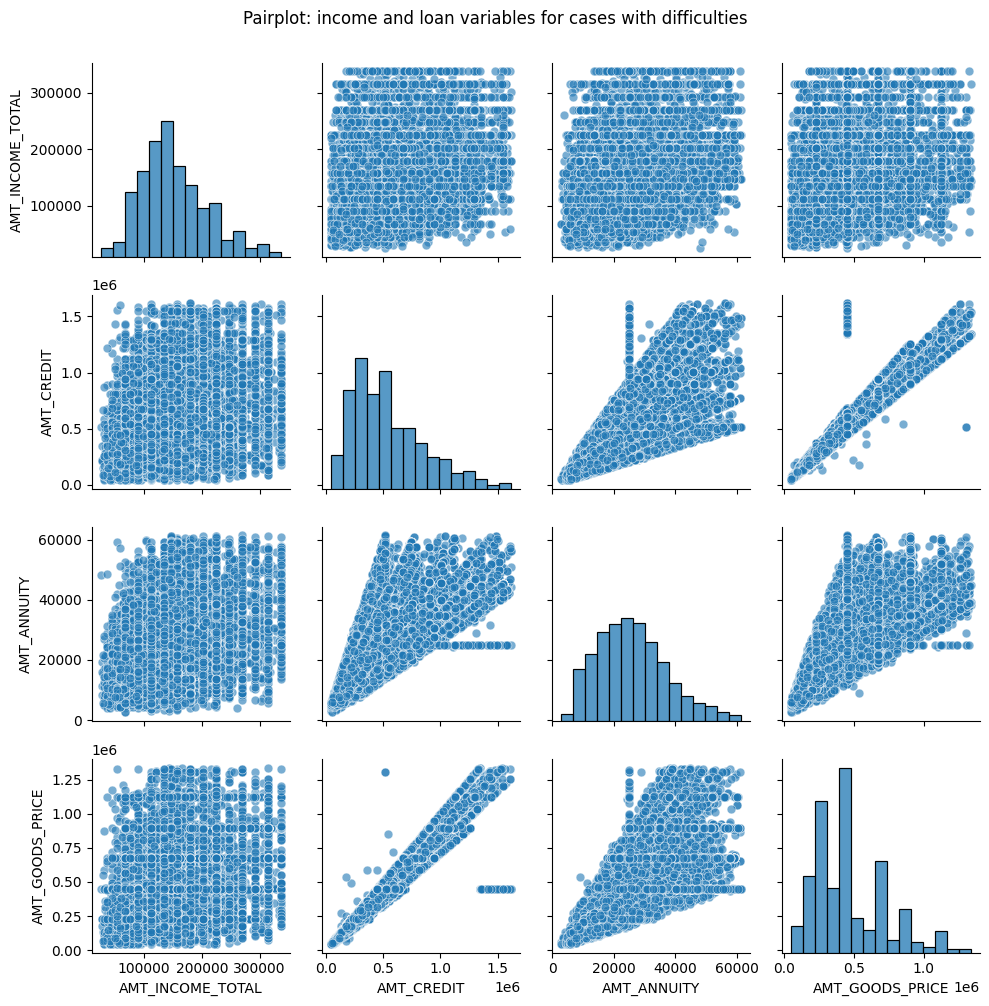

In [ ]:
df_pair1 = app_cleaned1[['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE']]

pairplot = sns.pairplot(df_pair1, diag_kind='hist', plot_kws={'alpha': 0.6, 's': 40}, diag_kws={'bins': 15})
pairplot.fig.suptitle('Pairplot: income and loan variables for cases with difficulties', y=1.001)
plt.tight_layout()
plt.show()

Top 6 Correlations (absolute value):


,Feature_1,Feature_2,Correlation
0,AMT_CREDIT,AMT_GOODS_PRICE,0.875417
1,CNT_CHILDREN,CNT_FAM_MEMBERS,0.851169
2,AMT_CREDIT,AMT_ANNUITY,0.724593
3,AMT_ANNUITY,AMT_GOODS_PRICE,0.684409
4,AMT_INCOME_TOTAL,AMT_ANNUITY,0.398119
5,CNT_CHILDREN,DAYS_BIRTH,0.343280


/tmp/ipykernel_830/3508856293.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Correlation', y=top_correlations_df['Feature_1'] + ' vs ' + top_correlations_df['Feature_2'],


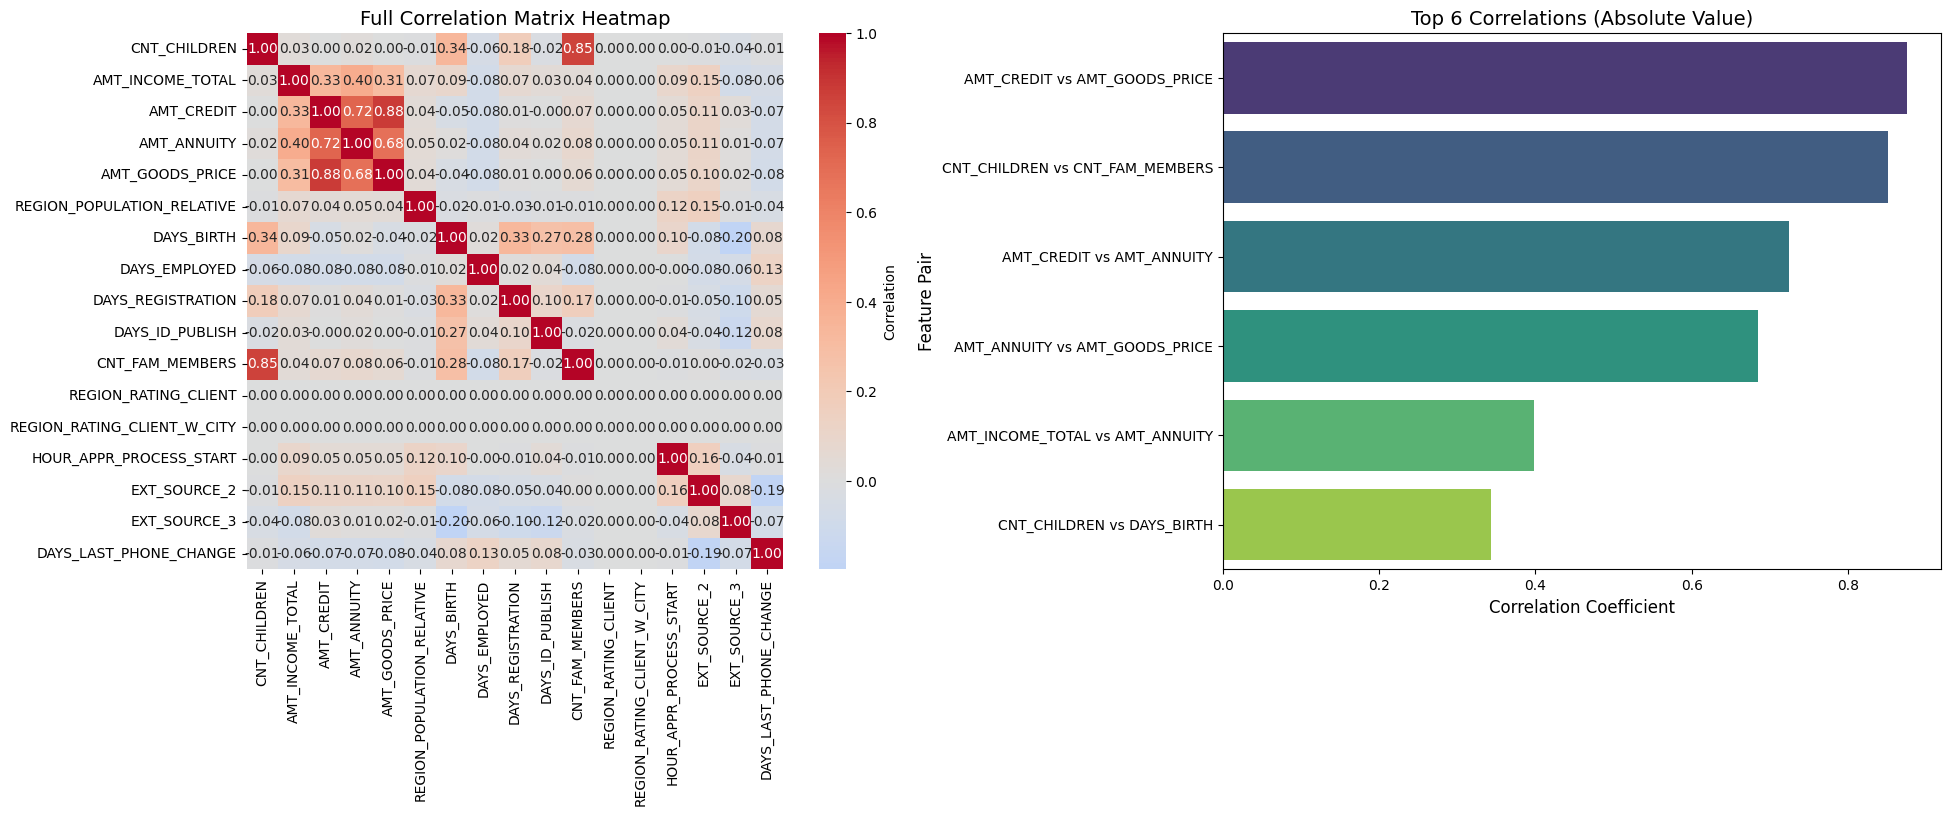

In [ ]:
plot_top_correlations_with_heatmap(corr0_matrix, n_top_correlations=6)

# Preprocessing Previous Applications

In [37]:
#Obtaining columns with more than 40% missing values
p_null_columns = papp.columns[papp.isnull().sum() / len(papp) * 100 > 40.0]

In [38]:
len(p_null_columns)

11

In [39]:
p_null_columns

Index(['AMT_DOWN_PAYMENT', 'RATE_DOWN_PAYMENT', 'RATE_INTEREST_PRIMARY',
       'RATE_INTEREST_PRIVILEGED', 'NAME_TYPE_SUITE', 'DAYS_FIRST_DRAWING',
       'DAYS_FIRST_DUE', 'DAYS_LAST_DUE_1ST_VERSION', 'DAYS_LAST_DUE',
       'DAYS_TERMINATION', 'NFLAG_INSURED_ON_APPROVAL'],
      dtype='object')

In [40]:
papp.drop(p_null_columns, axis=1, inplace=True)

In [41]:
papp.shape

(1670214, 26)

In [42]:
pnull_columns2 = papp.columns[papp.isnull().sum() > 0]

In [43]:
pnull_columns2

Index(['AMT_ANNUITY', 'AMT_CREDIT', 'AMT_GOODS_PRICE', 'CNT_PAYMENT',
       'PRODUCT_COMBINATION'],
      dtype='object')

In [44]:
papp[pnull_columns2].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1670214 entries, 0 to 1670213
Data columns (total 5 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   AMT_ANNUITY          1297979 non-null  float64
 1   AMT_CREDIT           1670213 non-null  float64
 2   AMT_GOODS_PRICE      1284699 non-null  float64
 3   CNT_PAYMENT          1297984 non-null  float64
 4   PRODUCT_COMBINATION  1669868 non-null  object 
dtypes: float64(4), object(1)
memory usage: 63.7+ MB


In [ ]:
len(papp)

1670214

In [ ]:
papp['AMT_ANNUITY'].isnull().sum() / len(papp) * 100

np.float64(22.286665062081866)

<Axes: >

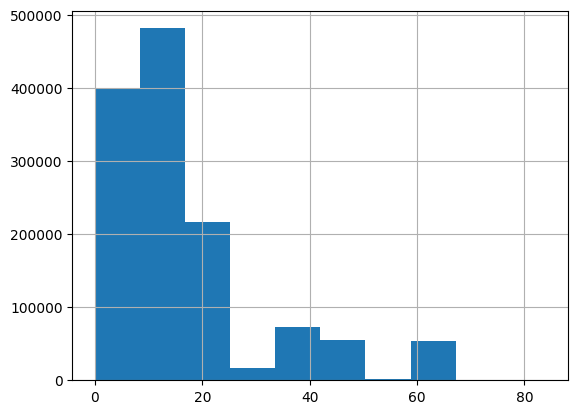

In [ ]:
papp['CNT_PAYMENT'].hist()


<Axes: >

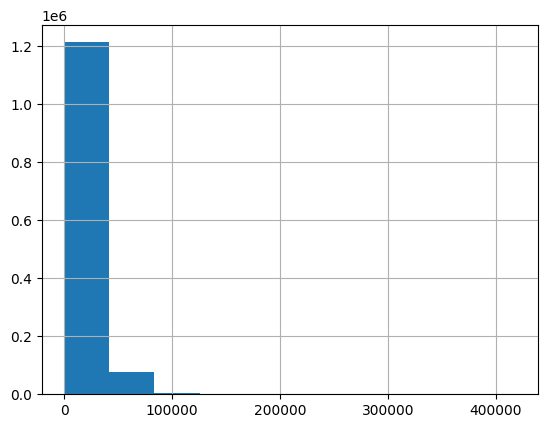

In [ ]:
papp['AMT_ANNUITY'].hist()

In [ ]:
papp['AMT_ANNUITY'].describe()

,AMT_ANNUITY
count,1.297979e+06
mean,1.595512e+04
std,1.478214e+04
min,0.000000e+00
25%,6.321780e+03
50%,1.125000e+04
75%,2.065842e+04
max,4.180581e+05


In [ ]:
papp['AMT_GOODS_PRICE'].describe()

,AMT_GOODS_PRICE
count,1.284699e+06
mean,2.278473e+05
std,3.153966e+05
min,0.000000e+00
25%,5.084100e+04
50%,1.123200e+05
75%,2.340000e+05
max,6.905160e+06


<Axes: >

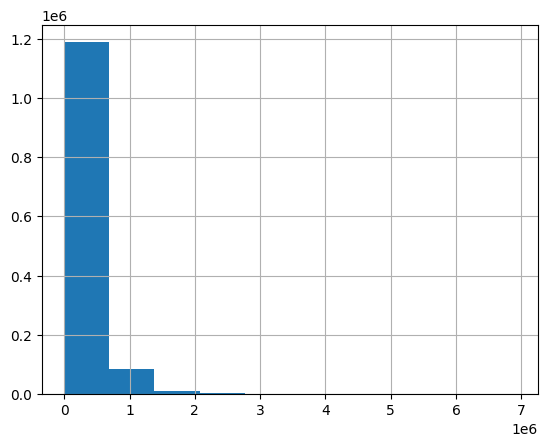

In [ ]:
papp['AMT_GOODS_PRICE'].hist()

<Axes: ylabel='PRODUCT_COMBINATION'>

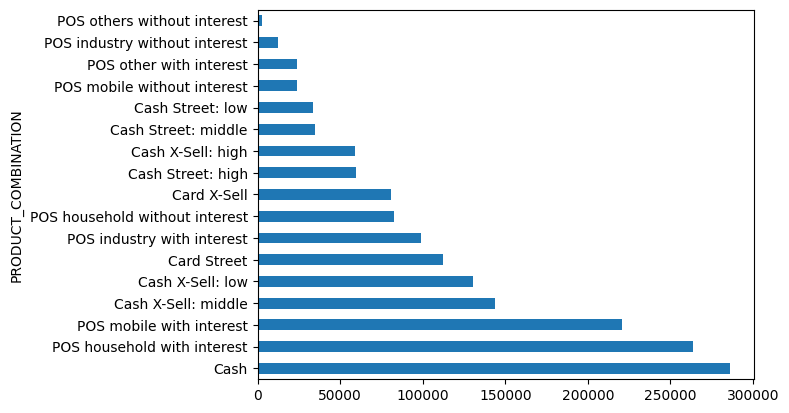

In [ ]:
papp['PRODUCT_COMBINATION'].value_counts().plot(kind='barh')

Replacing the Missing Values with Median and Mode

In [46]:
papp['AMT_ANNUITY'].fillna(papp['AMT_ANNUITY'].median(), inplace=True)
papp['AMT_GOODS_PRICE'].fillna(papp['AMT_GOODS_PRICE'].median(), inplace=True)
papp['CNT_PAYMENT'].fillna(papp['CNT_PAYMENT'].median(), inplace=True)
papp['AMT_CREDIT'].fillna(papp['AMT_CREDIT'].median(), inplace=True)
papp['PRODUCT_COMBINATION'].fillna(papp['PRODUCT_COMBINATION'].mode()[0], inplace=True)

/tmp/ipykernel_4345/3520480336.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  papp['AMT_ANNUITY'].fillna(papp['AMT_ANNUITY'].median(), inplace=True)
/tmp/ipykernel_4345/3520480336.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value

In [47]:
papp.AMT_CREDIT.isnull().sum()

np.int64(0)

In [48]:
papp.columns

Index(['SK_ID_PREV', 'SK_ID_CURR', 'NAME_CONTRACT_TYPE', 'AMT_ANNUITY',
       'AMT_APPLICATION', 'AMT_CREDIT', 'AMT_GOODS_PRICE',
       'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START',
       'FLAG_LAST_APPL_PER_CONTRACT', 'NFLAG_LAST_APPL_IN_DAY',
       'NAME_CASH_LOAN_PURPOSE', 'NAME_CONTRACT_STATUS', 'DAYS_DECISION',
       'NAME_PAYMENT_TYPE', 'CODE_REJECT_REASON', 'NAME_CLIENT_TYPE',
       'NAME_GOODS_CATEGORY', 'NAME_PORTFOLIO', 'NAME_PRODUCT_TYPE',
       'CHANNEL_TYPE', 'SELLERPLACE_AREA', 'NAME_SELLER_INDUSTRY',
       'CNT_PAYMENT', 'NAME_YIELD_GROUP', 'PRODUCT_COMBINATION'],
      dtype='object')

<Axes: ylabel='CODE_REJECT_REASON'>

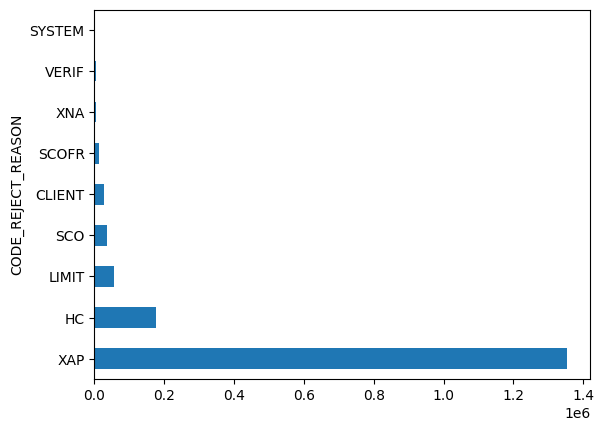

In [ ]:
papp['CODE_REJECT_REASON'].value_counts().plot(kind='barh')

In [45]:
p_numeric_cols = papp.select_dtypes(include=[np.number]).columns.tolist()

#Separate Continous columns with binary flag
p_continuous_cols = []
p_binary_cols = []

for col in p_numeric_cols:
  if papp[col].nunique() == 2:
    p_binary_cols.append(col)
  else:
    p_continuous_cols.append(col)

print(f"📊 Found {len(p_continuous_cols)} Truly Continuous Columns.")
print(f"🚩 Found {len(p_binary_cols)} Binary Flag Columns (0 and 1).")

📊 Found 10 Truly Continuous Columns.
🚩 Found 1 Binary Flag Columns (0 and 1).


In [49]:
p_binary_cols

['NFLAG_LAST_APPL_IN_DAY']

In [50]:
p_continuous_cols

['SK_ID_PREV',
 'SK_ID_CURR',
 'AMT_ANNUITY',
 'AMT_APPLICATION',
 'AMT_CREDIT',
 'AMT_GOODS_PRICE',
 'HOUR_APPR_PROCESS_START',
 'DAYS_DECISION',
 'SELLERPLACE_AREA',
 'CNT_PAYMENT']

In [51]:
p_continuous_cols.remove('SK_ID_CURR')
p_continuous_cols.remove('SK_ID_PREV')

In [52]:
len(p_continuous_cols)

8

## Replacing outliers with median

In [53]:
papp_cleaned = handle_outliers_with_median(papp, p_numeric_cols)

In [ ]:
papp_cleaned.describe()

,SK_ID_PREV,SK_ID_CURR,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_GOODS_PRICE,HOUR_APPR_PROCESS_START,NFLAG_LAST_APPL_IN_DAY,DAYS_DECISION,SELLERPLACE_AREA,CNT_PAYMENT
count,1.670214e+06,1.670214e+06,1.670214e+06,1.670214e+06,1.670214e+06,1.670214e+06,1.670214e+06,1670214.0,1.670214e+06,1.670214e+06,1.670214e+06
mean,1.923089e+06,2.783572e+05,1.144079e+04,8.294869e+04,1.018242e+05,1.095461e+05,1.249171e+01,1.0,-8.565417e+02,2.047193e+01,1.221726e+01
std,5.325980e+05,1.028148e+05,5.933819e+03,8.588188e+04,1.104948e+05,6.249967e+04,3.316954e+00,0.0,7.519909e+02,4.074718e+01,4.429259e+00
min,1.000001e+06,1.000010e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.000000e+00,1.0,-2.830000e+03,-1.000000e+00,3.000000e+00
25%,1.461857e+06,1.893290e+05,7.547096e+03,1.872000e+04,2.416050e+04,6.750000e+04,1.000000e+01,1.0,-1.249000e+03,-1.000000e+00,1.200000e+01
50%,1.923110e+06,2.787145e+05,1.125000e+04,7.104600e+04,8.054100e+04,1.123200e+05,1.200000e+01,1.0,-5.810000e+02,3.000000e+00,1.200000e+01
75%,2.384280e+06,3.675140e+05,1.251905e+04,1.125900e+05,1.350000e+05,1.123200e+05,1.500000e+01,1.0,-2.800000e+02,2.500000e+01,1.200000e+01
max,2.845382e+06,4.562550e+05,3.073919e+04,4.228200e+05,5.048055e+05,3.497625e+05,2.200000e+01,1.0,-1.000000e+00,2.060000e+02,2.400000e+01


/tmp/ipykernel_830/3602543566.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_830/3602543566.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_830/3602543566.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_830/3602543566.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_830/3602543566.py:25: FutureWarning: 

Passin

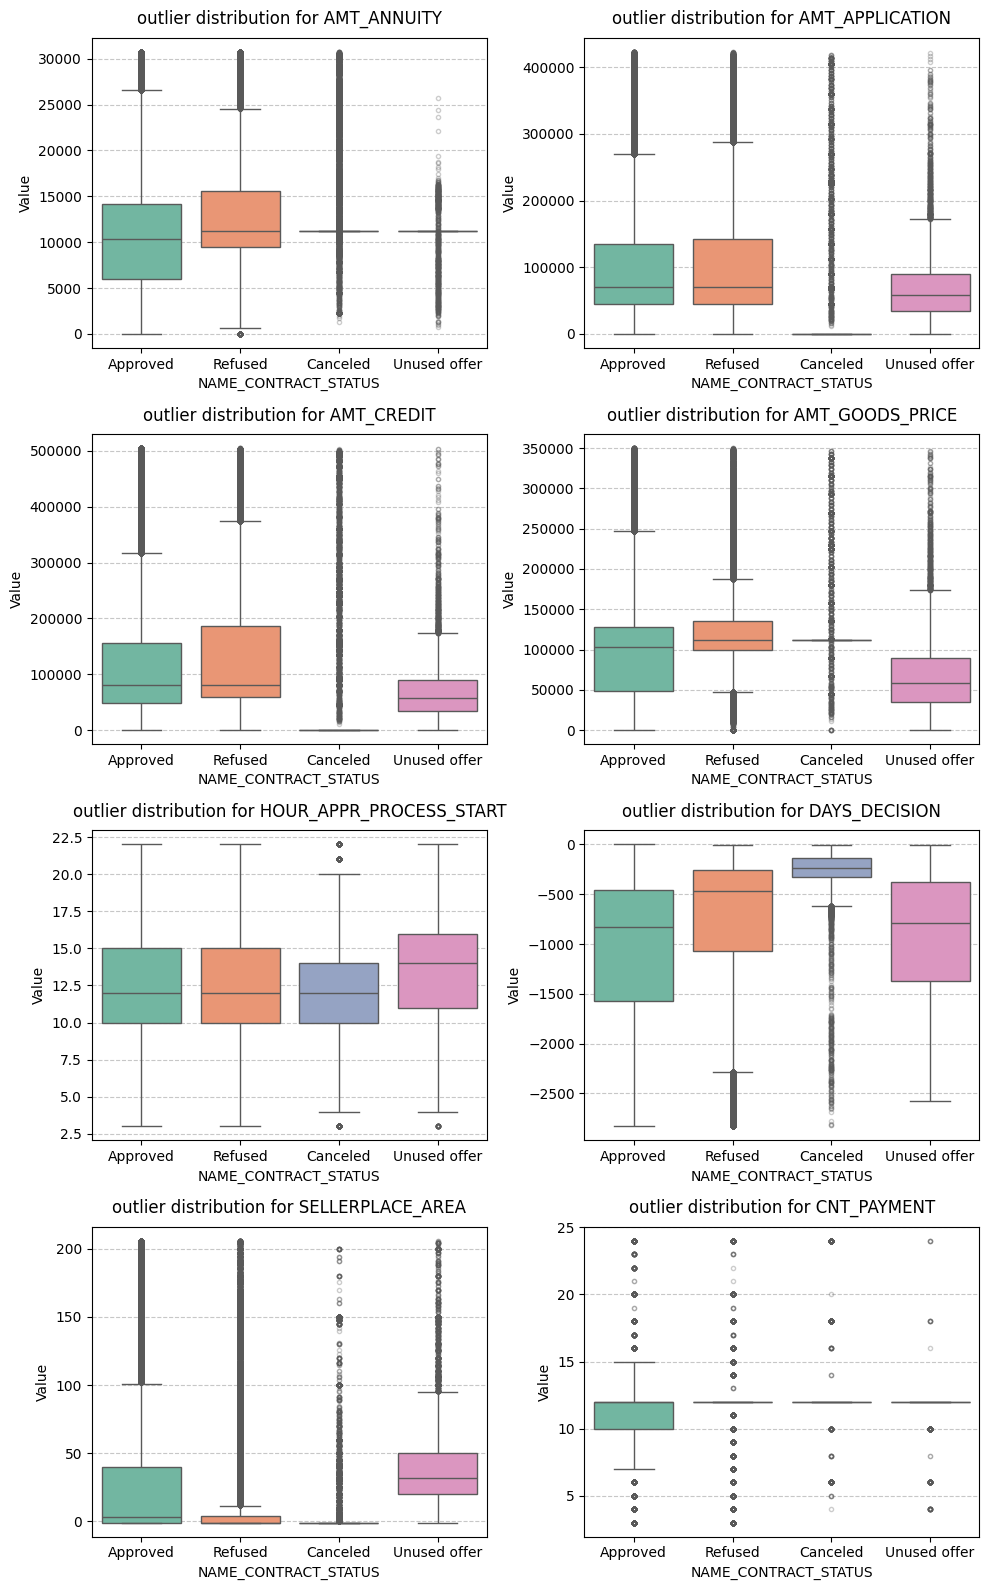

In [ ]:
box_plot_grid(papp_cleaned, p_continuous_cols, target="NAME_CONTRACT_STATUS", num_cols=2)

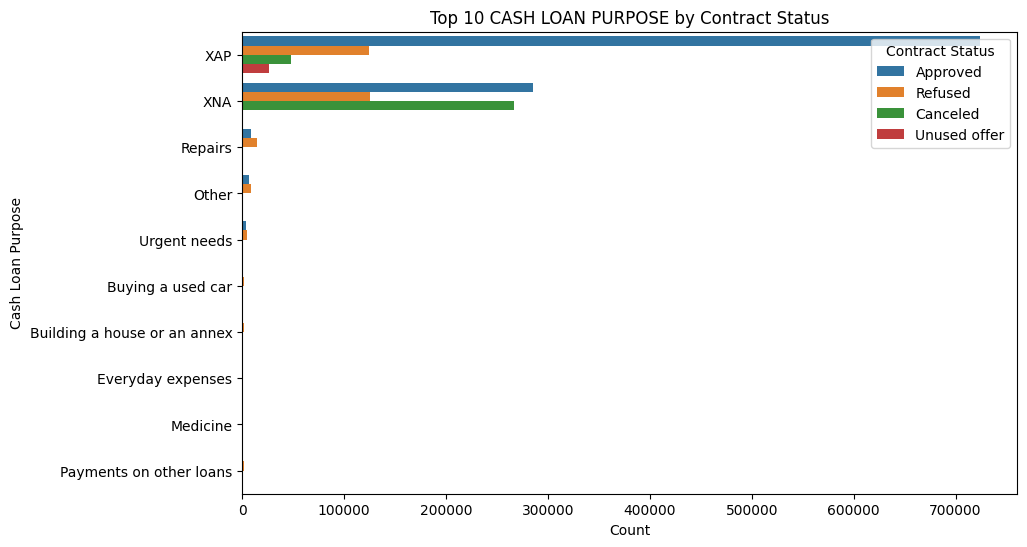

In [ ]:
# 1. Get the list of top 10 category names by raw volume
top_10_purpose = papp['NAME_CASH_LOAN_PURPOSE'].value_counts().head(10).index

# 2. Filter the original dataframe and plot using seaborn
plt.figure(figsize=(10, 6))
sns.countplot(
    data=papp[papp['NAME_CASH_LOAN_PURPOSE'].isin(top_10_purpose)],
    y='NAME_CASH_LOAN_PURPOSE',
    hue='NAME_CONTRACT_STATUS',
    order=top_10_purpose  # Keeps them sorted beautifully from highest to lowest count
)
plt.title('Top 10 CASH LOAN PURPOSE by Contract Status')
plt.xlabel('Count')
plt.ylabel('Cash Loan Purpose')
plt.legend(title='Contract Status', loc='upper right')
plt.show()

### Merging the dataframes

In [54]:
print(papp_cleaned.shape)
print(app_cleaned.shape)

(1670214, 26)
(307511, 63)


In [55]:
df = pd.merge(papp_cleaned, app_cleaned, on='SK_ID_CURR', how='left')

In [56]:
df.shape

(1670214, 88)

In [57]:
#df.to_csv('/content/EDA_final.csv', index=False)

In [58]:
df.columns

Index(['SK_ID_PREV', 'SK_ID_CURR', 'NAME_CONTRACT_TYPE_x', 'AMT_ANNUITY_x',
       'AMT_APPLICATION', 'AMT_CREDIT_x', 'AMT_GOODS_PRICE_x',
       'WEEKDAY_APPR_PROCESS_START_x', 'HOUR_APPR_PROCESS_START_x',
       'FLAG_LAST_APPL_PER_CONTRACT', 'NFLAG_LAST_APPL_IN_DAY',
       'NAME_CASH_LOAN_PURPOSE', 'NAME_CONTRACT_STATUS', 'DAYS_DECISION',
       'NAME_PAYMENT_TYPE', 'CODE_REJECT_REASON', 'NAME_CLIENT_TYPE',
       'NAME_GOODS_CATEGORY', 'NAME_PORTFOLIO', 'NAME_PRODUCT_TYPE',
       'CHANNEL_TYPE', 'SELLERPLACE_AREA', 'NAME_SELLER_INDUSTRY',
       'CNT_PAYMENT', 'NAME_YIELD_GROUP', 'PRODUCT_COMBINATION', 'TARGET',
       'NAME_CONTRACT_TYPE_y', 'CODE_GENDER', 'FLAG_OWN_CAR',
       'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT_y',
       'AMT_ANNUITY_y', 'AMT_GOODS_PRICE_y', 'NAME_TYPE_SUITE',
       'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS',
       'NAME_HOUSING_TYPE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH',
       'DAYS_EMPLOYED', 'D

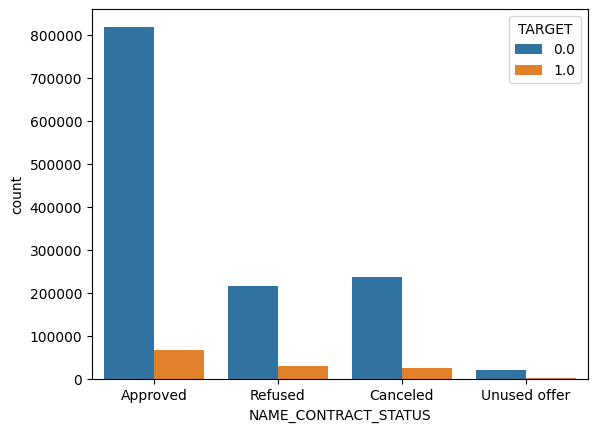

In [ ]:
sns.countplot(data=df, x='NAME_CONTRACT_STATUS', hue='TARGET')
plt.show()

<Axes: xlabel='TARGET'>

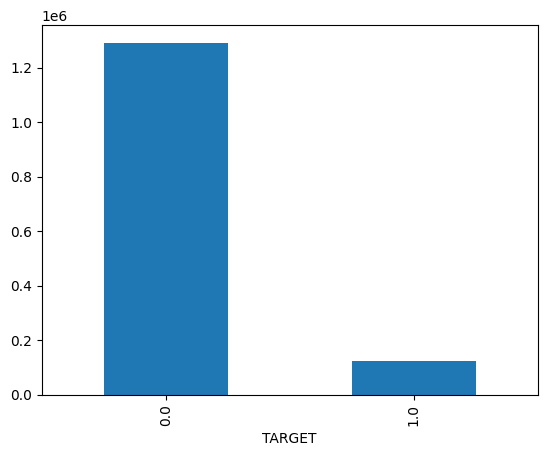

In [61]:
df['TARGET'].value_counts().plot(kind='bar')

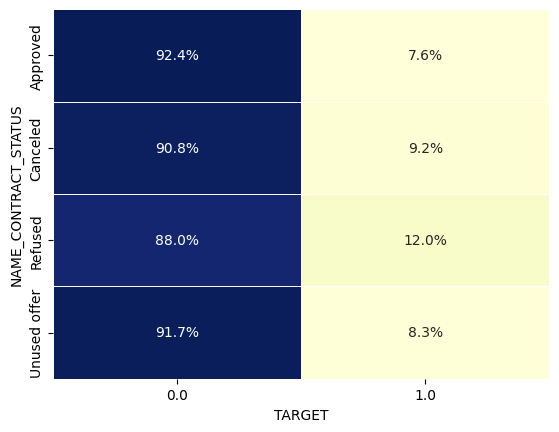

In [62]:
pm = pd.crosstab(index=df['NAME_CONTRACT_STATUS'], columns=df['TARGET'], normalize='index')

sns.heatmap(data = pm,
            annot=True,
            fmt=".1%",
            cmap = "YlGnBu",
            linewidths= 0.5,
            cbar=False)
plt.show()

In [64]:
df1 = df[df['TARGET'] == 1]

In [65]:
df1.shape

(122360, 88)

In [66]:
len(df1)/len(df) * 100

7.326007326007327

In [67]:
f_numeric_cols = df1.select_dtypes(include=[np.number]).columns.tolist()

#Separate Continous columns with binary flag
f_continuous_cols = []
f_binary_cols = []

for col in f_numeric_cols:
  if df1[col].nunique() == 2:
    f_binary_cols.append(col)
  else:
    f_continuous_cols.append(col)

print(f"📊 Found {len(f_continuous_cols)} Truly Continuous Columns.")
print(f"🚩 Found {len(f_binary_cols)} Binary Flag Columns (0 and 1).")

📊 Found 34 Truly Continuous Columns.
🚩 Found 27 Binary Flag Columns (0 and 1).


In [68]:
f_continuous_cols.remove('SK_ID_CURR')
f_continuous_cols.remove('SK_ID_PREV')

In [69]:
f_continuous_cols

['AMT_ANNUITY_x',
 'AMT_APPLICATION',
 'AMT_CREDIT_x',
 'AMT_GOODS_PRICE_x',
 'HOUR_APPR_PROCESS_START_x',
 'NFLAG_LAST_APPL_IN_DAY',
 'DAYS_DECISION',
 'SELLERPLACE_AREA',
 'CNT_PAYMENT',
 'TARGET',
 'CNT_CHILDREN',
 'AMT_INCOME_TOTAL',
 'AMT_CREDIT_y',
 'AMT_ANNUITY_y',
 'AMT_GOODS_PRICE_y',
 'REGION_POPULATION_RELATIVE',
 'DAYS_BIRTH',
 'DAYS_EMPLOYED',
 'DAYS_REGISTRATION',
 'DAYS_ID_PUBLISH',
 'FLAG_MOBIL',
 'CNT_FAM_MEMBERS',
 'REGION_RATING_CLIENT',
 'REGION_RATING_CLIENT_W_CITY',
 'HOUR_APPR_PROCESS_START_y',
 'EXT_SOURCE_2',
 'EXT_SOURCE_3',
 'DAYS_LAST_PHONE_CHANGE',
 'FLAG_DOCUMENT_4',
 'FLAG_DOCUMENT_10',
 'FLAG_DOCUMENT_12',
 'FLAG_DOCUMENT_17']

In [76]:
df1['FLAG_DOCUMENT_4'].nunique()

1

In [73]:
f_binary_cols

['FLAG_EMP_PHONE',
 'FLAG_WORK_PHONE',
 'FLAG_CONT_MOBILE',
 'FLAG_PHONE',
 'FLAG_EMAIL',
 'REG_REGION_NOT_LIVE_REGION',
 'REG_REGION_NOT_WORK_REGION',
 'LIVE_REGION_NOT_WORK_REGION',
 'REG_CITY_NOT_LIVE_CITY',
 'REG_CITY_NOT_WORK_CITY',
 'LIVE_CITY_NOT_WORK_CITY',
 'FLAG_DOCUMENT_2',
 'FLAG_DOCUMENT_3',
 'FLAG_DOCUMENT_5',
 'FLAG_DOCUMENT_6',
 'FLAG_DOCUMENT_7',
 'FLAG_DOCUMENT_8',
 'FLAG_DOCUMENT_9',
 'FLAG_DOCUMENT_11',
 'FLAG_DOCUMENT_13',
 'FLAG_DOCUMENT_14',
 'FLAG_DOCUMENT_15',
 'FLAG_DOCUMENT_16',
 'FLAG_DOCUMENT_18',
 'FLAG_DOCUMENT_19',
 'FLAG_DOCUMENT_20',
 'FLAG_DOCUMENT_21']

In [74]:
##removing flag variables from continous cols
f_continuous_cols.remove('FLAG_DOCUMENT_4')
f_continuous_cols.remove('FLAG_DOCUMENT_10')
f_continuous_cols.remove('FLAG_DOCUMENT_12')
f_continuous_cols.remove('FLAG_DOCUMENT_17')

##Updating binary cols
f_binary_cols.append('FLAG_DOCUMENT_4')
f_binary_cols.append('FLAG_DOCUMENT_10')
f_binary_cols.append('FLAG_DOCUMENT_12')
f_binary_cols.append('FLAG_DOCUMENT_17')



In [77]:
len(f_continuous_cols)

28

In [95]:
#df1[f_continuous_cols].isnull().sum()

In [96]:
#df1[['AMT_GOODS_PRICE_y','EXT_SOURCE_2','EXT_SOURCE_3']].describe()

In [97]:
#len(df1)

In [98]:
#23378/len(df1) * 100

In [83]:
df1['AMT_GOODS_PRICE_y'].fillna(df1['AMT_GOODS_PRICE_y'].median(), inplace=True)

/tmp/ipykernel_4345/251839952.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df1['AMT_GOODS_PRICE_y'].fillna(df1['AMT_GOODS_PRICE_y'].median(), inplace=True)
/tmp/ipykernel_4345/251839952.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['AMT_GOODS_PRICE_y'].fillna(df1['AMT_GOODS_PRICE_y'].median(), inplace=True)


In [84]:
df1['EXT_SOURCE_2'].fillna(df1['EXT_SOURCE_2'].median(), inplace=True)
df1.drop('EXT_SOURCE_3', axis=1, inplace=True) ##Almost 20% null values and normalized scores hence I am dropping

/tmp/ipykernel_4345/3043967533.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df1['EXT_SOURCE_2'].fillna(df1['EXT_SOURCE_2'].median(), inplace=True)
/tmp/ipykernel_4345/3043967533.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['EXT_SOURCE_2'].fillna(df1['EXT_SOURCE_2'].median(), inplace=True)
/tmp/ipykernel_4345/3043967533.py:2: 

In [85]:
df1_cleaned = handle_outliers_with_median(df1, f_continuous_cols)

In [88]:
f_continuous_cols.remove('EXT_SOURCE_3')

In [89]:
final_corr_matrix = df1_cleaned[f_continuous_cols].corr()

Top 6 Correlations (absolute value):


,Feature_1,Feature_2,Correlation
0,AMT_CREDIT_y,AMT_GOODS_PRICE_y,0.934648
1,AMT_APPLICATION,AMT_CREDIT_x,0.875556
2,CNT_CHILDREN,CNT_FAM_MEMBERS,0.855424
3,AMT_ANNUITY_x,AMT_GOODS_PRICE_x,0.696950
4,AMT_CREDIT_y,AMT_ANNUITY_y,0.696246
5,AMT_ANNUITY_y,AMT_GOODS_PRICE_y,0.695336


/tmp/ipykernel_4345/3508856293.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Correlation', y=top_correlations_df['Feature_1'] + ' vs ' + top_correlations_df['Feature_2'],


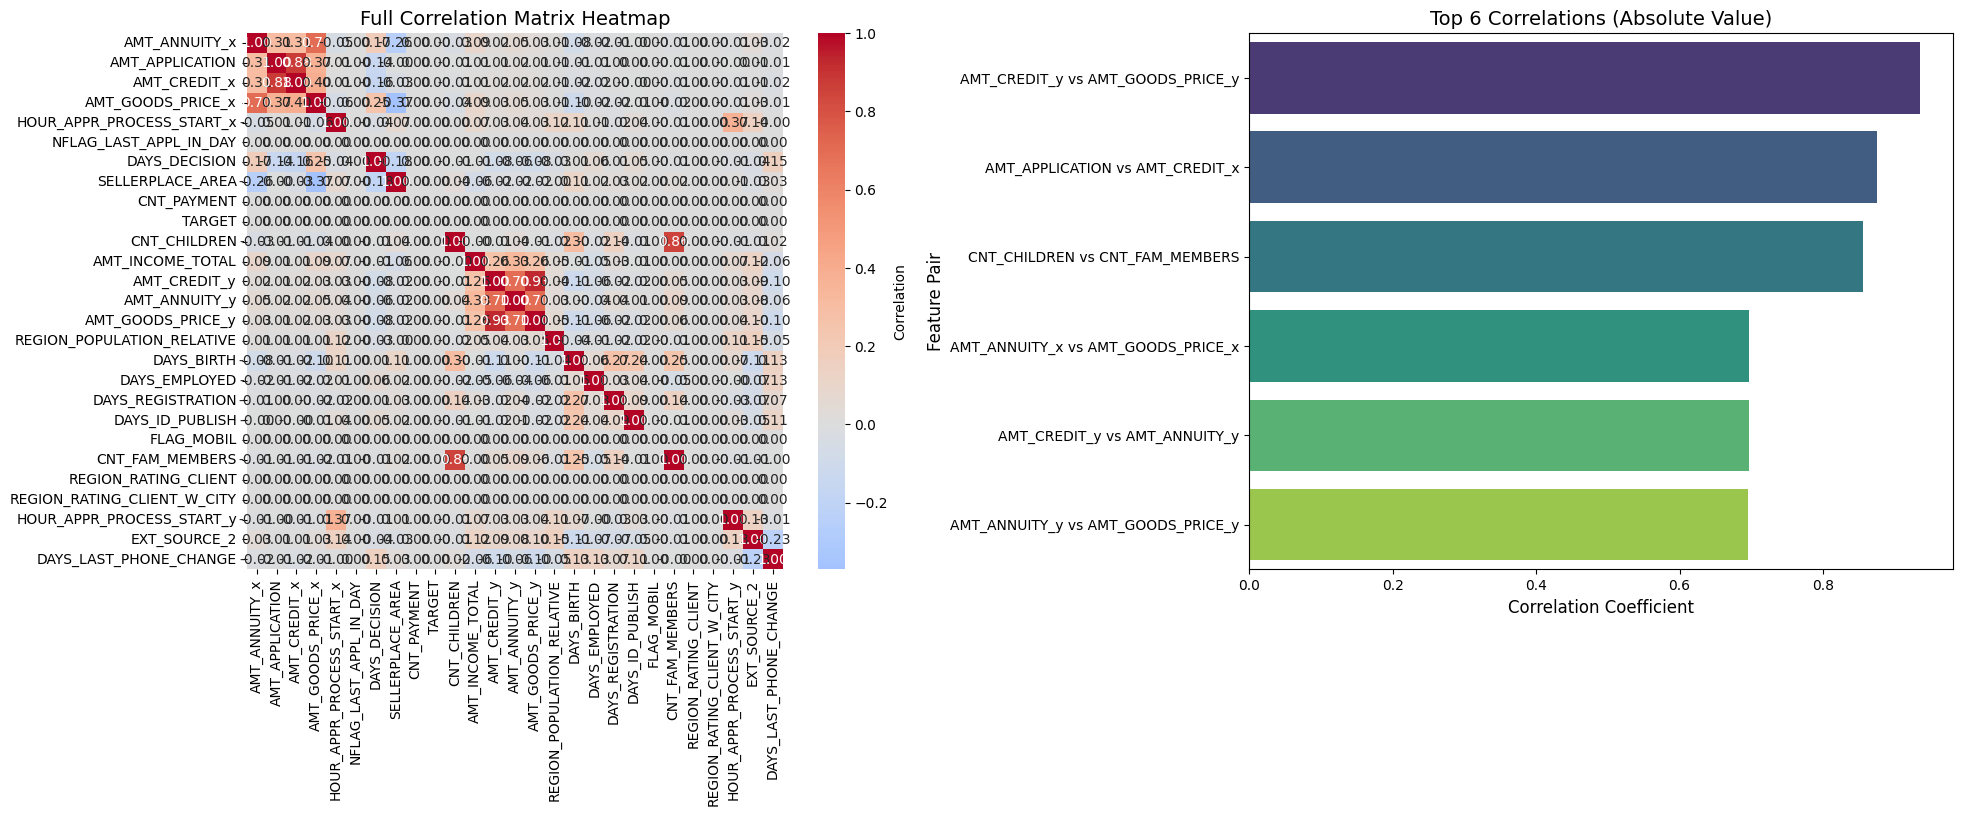

In [90]:
plot_top_correlations_with_heatmap(final_corr_matrix, n_top_correlations=6)

In [100]:
df1[['AMT_APPLICATION', 'AMT_CREDIT_x']].head(10)

,AMT_APPLICATION,AMT_CREDIT_x
27,247500.00,268083.00
52,45000.00,47970.00
58,72000.00,72000.00
63,0.00,0.00
94,71046.00,80541.00
172,112500.00,127350.00
192,129060.00,116154.00
214,30271.59,33268.59
224,0.00,0.00
229,0.00,0.00


/tmp/ipykernel_4345/359814607.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='TARGET', loc='upper right')


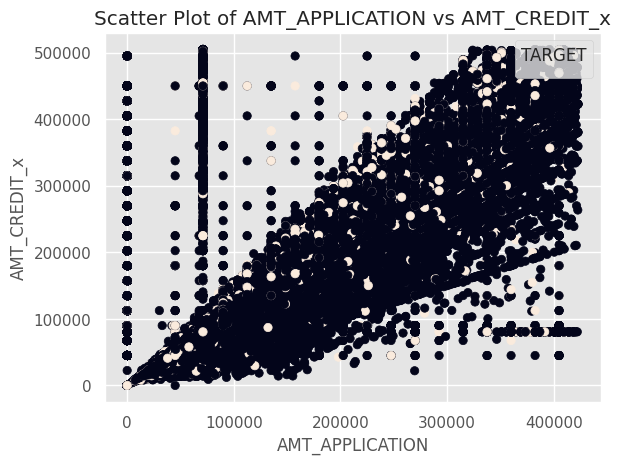

In [107]:
plt.style.use('ggplot')
plt.scatter(df['AMT_APPLICATION'], df['AMT_CREDIT_x'], c=df['TARGET'])
plt.xlabel('AMT_APPLICATION')
plt.ylabel('AMT_CREDIT_x')
plt.legend(title='TARGET', loc='upper right')
plt.title('Scatter Plot of AMT_APPLICATION vs AMT_CREDIT_x')
plt.show()

# KEY TAKEAWAYS


1.  In the applications dataset, approximately 8% people had payment difficulties at the time of application but when we look at the proportion matrix we see that women on maternity leave, unemployed people and FLAG_DOCUMENT_2's proportion we significantly higher i.e. 40%, 63.6% and and 30.8%. So fair attention should be given for these demographics while processing their applications.  
2.   For people who face difficulty, the credit amount of the loan has high correlation with price of the goods for which the loan is given, and the loan annuity & has comparatively little correlation with income of the client. However the income more correlated with loan annuity and loan annuity has a higher correlation with price of goods. A similar pattern can be seen for people who don't have difficulties as well(although the strenght of correlations differ)
3. 12% of the people who have difficulties have been refused a loan. On subsequent analysis, we see that their requested credit amount(AMT_APPLICATION) and the final credit granted(AMT_CREDIT) we highly correlated

